# 🚀 YOLO Multi-Version Training Pipeline (Kaggle)
### YOLOv8 → YOLOv9 → YOLOv10

This notebook trains YOLOv8, YOLOv9, and YOLOv10 on the same dataset and saves:
- Trained weights (`best.pt`, `last.pt`)
- Training curves (loss, mAP, precision, recall)
- Confusion matrix, PR curve, F1 curve
- Validation prediction samples
- Detection results on test images
- Final comparison summary CSV

**Kaggle paths:** Input data lives under `/kaggle/input/`, outputs go to `/kaggle/working/`.

---

---
## 📁 CELL 1: Kaggle Environment Check


In [1]:
import os

# Kaggle provides GPU — verify
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# List available input datasets
print("\n📂 /kaggle/input contents:")
for d in os.listdir('/kaggle/input'):
    print(f"  {d}")


CUDA available: True
GPU: Tesla T4

📂 /kaggle/input contents:
  datasets


---
## ⚙️ CELL 2: Global Configuration
**Edit these paths and hyperparameters before running.**

In [2]:
# ──────────────────────────────────────────────
#  USER CONFIGURATION — Edit these values
# ──────────────────────────────────────────────

# ⬇️  Point this to your Kaggle input dataset folder
# e.g. '/kaggle/input/my-dataset/raw_data'
RAW_DATA_PATH = "/kaggle/input/datasets/tamimresearch/rice-false-smut/raw_data"   # ← update dataset name
TEST_SOURCE   = "/kaggle/input/datasets/tamimresearch/rice-false-smut/test_data"       # ← test images folder

# All outputs go to /kaggle/working (persisted after run)
BASE_PATH     = "/kaggle/working/yolo_comparison"

# Shared hyperparameters
EPOCHS      = 100
IMG_SIZE    = 640
BATCH_SIZE  = 16
VAL_SPLIT   = 0.2
CONF_THRES  = 0.1
NUM_CLASSES = 4
CLASS_NAMES = ["initial", "yellow", "transition", "last"]   # e.g. ["cat", "dog", "car"]
# ──────────────────────────────────────────────

# Output folder structure
DATASET_PATH = f"{BASE_PATH}/dataset"
RESULTS_PATH = f"{BASE_PATH}/results"

TRAIN_IMG = f"{DATASET_PATH}/images/train"
VAL_IMG   = f"{DATASET_PATH}/images/val"
TRAIN_LBL = f"{DATASET_PATH}/labels/train"
VAL_LBL   = f"{DATASET_PATH}/labels/val"

for d in [TRAIN_IMG, VAL_IMG, TRAIN_LBL, VAL_LBL, RESULTS_PATH]:
    os.makedirs(d, exist_ok=True)

print("✅ Configuration loaded.")
print(f"   Base path  : {BASE_PATH}")
print(f"   Dataset    : {DATASET_PATH}")
print(f"   Results    : {RESULTS_PATH}")


✅ Configuration loaded.
   Base path  : /kaggle/working/yolo_comparison
   Dataset    : /kaggle/working/yolo_comparison/dataset
   Results    : /kaggle/working/yolo_comparison/results


---
## 📦 CELL 3: Install All YOLO Packages

In [3]:
# Ultralytics covers YOLOv8, YOLOv9, YOLOv10
!pip install -U ultralytics

print("✅ All packages installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.5 MB/s eta 0:00:0000:01
✅ All packages installed.


---
## 📂 CELL 4: Imports

In [4]:
import os, shutil, random, csv, glob, json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from tqdm.notebook import tqdm
from IPython.display import display, Image as IPImage
from ultralytics import YOLO

USE_GPU = torch.cuda.is_available()
DEVICE  = 0 if USE_GPU else 'cpu'
print(f"GPU Available: {USE_GPU}  |  Device: {DEVICE}")

# Track results across versions
SUMMARY = []

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU Available: True  |  Device: 0


---
## 🗂️ CELL 5: Train / Val Split & data.yaml

In [5]:
def train_val_split(path, split=VAL_SPLIT):
    files = list(set([f[:-4] for f in os.listdir(path) if f.endswith('.jpg')]))
    random.seed(42)
    random.shuffle(files)
    val_size    = int(len(files) * split)
    train_files = files[val_size:]
    val_files   = files[:val_size]
    print(f"Total: {len(files)} | Train: {len(train_files)} | Val: {len(val_files)}")
    for f in tqdm(train_files, desc='Copying train'):
        shutil.copy2(f"{path}/{f}.jpg", f"{TRAIN_IMG}/{f}.jpg")
        shutil.copy2(f"{path}/{f}.txt", f"{TRAIN_LBL}/{f}.txt")
    for f in tqdm(val_files, desc='Copying val'):
        shutil.copy2(f"{path}/{f}.jpg", f"{VAL_IMG}/{f}.jpg")
        shutil.copy2(f"{path}/{f}.txt", f"{VAL_LBL}/{f}.txt")

# Run split only if images not already copied
if len(os.listdir(TRAIN_IMG)) == 0:
    train_val_split(RAW_DATA_PATH)
else:
    print("⏭️  Dataset already split, skipping.")

# Write data.yaml
DATA_YAML = f"{DATASET_PATH}/data.yaml"
yaml_content = f"""train: {TRAIN_IMG}
val: {VAL_IMG}
nc: {NUM_CLASSES}
names: {CLASS_NAMES}
"""
with open(DATA_YAML, 'w') as f:
    f.write(yaml_content)
print(f"✅ data.yaml written to {DATA_YAML}")
print(yaml_content)

Total: 3125 | Train: 2500 | Val: 625


Copying train:   0%|          | 0/2500 [00:00<?, ?it/s]

Copying val:   0%|          | 0/625 [00:00<?, ?it/s]

✅ data.yaml written to /kaggle/working/yolo_comparison/dataset/data.yaml
train: /kaggle/working/yolo_comparison/dataset/images/train
val: /kaggle/working/yolo_comparison/dataset/images/val
nc: 4
names: ['initial', 'yellow', 'transition', 'last']



---
## 🛠️ CELL 6: Helper — Save Results


In [6]:
def copy_results_to_drive(run_dir, version_name):
    """Copy result files from a YOLO run directory to /kaggle/working results folder."""
    dest = f"{RESULTS_PATH}/{version_name}"
    os.makedirs(dest, exist_ok=True)

    exts = ['*.png', '*.jpg', '*.jpeg', '*.csv', '*.yaml',
            '*.txt', '*.pt', '*.json', '*.pdf']
    copied = 0
    for ext in exts:
        for src in glob.glob(f"{run_dir}/**/{ext}", recursive=True):
            rel = os.path.relpath(src, run_dir)
            dst = os.path.join(dest, rel)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy2(src, dst)
            copied += 1
    print(f"  📁 Copied {copied} files → {dest}")
    return dest


def extract_metrics(run_dir, version_name):
    """Extract final mAP50, mAP50-95, Precision, Recall from results.csv."""
    results_csv = glob.glob(f"{run_dir}/**/results.csv", recursive=True)
    if not results_csv:
        print(f"  ⚠️  No results.csv found for {version_name}")
        return None
    df = pd.read_csv(results_csv[0])
    df.columns = df.columns.str.strip()
    last = df.iloc[-1]
    metrics = {
        'version'   : version_name,
        'epochs'    : len(df),
        'mAP50'     : round(float(last.get('metrics/mAP50(B)',    last.get('metrics/mAP_0.5',      0))), 4),
        'mAP50-95'  : round(float(last.get('metrics/mAP50-95(B)', last.get('metrics/mAP_0.5:0.95', 0))), 4),
        'precision' : round(float(last.get('metrics/precision(B)', last.get('metrics/precision',   0))), 4),
        'recall'    : round(float(last.get('metrics/recall(B)',    last.get('metrics/recall',      0))), 4),
    }
    print(f"  📊 {version_name} | mAP50={metrics['mAP50']} | mAP50-95={metrics['mAP50-95']} "
          f"| P={metrics['precision']} | R={metrics['recall']}")
    return metrics


def show_result_images(run_dir, version_name, max_imgs=4):
    """Display key result plots inline."""
    target_files = [
        'results.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png',
        'PR_curve.png', 'F1_curve.png', 'P_curve.png', 'R_curve.png',
        'val_batch0_pred.jpg'
    ]
    found = []
    for fname in target_files:
        hits = glob.glob(f"{run_dir}/**/{fname}", recursive=True)
        if hits:
            found.append(hits[0])
    print(f"\n📸 {version_name} — Result Plots")
    for fpath in found[:max_imgs]:
        display(IPImage(fpath, width=700))

print("✅ Helper functions defined.")


✅ Helper functions defined.


---
# 1️⃣  YOLOv8 Training

  TRAINING YOLOv8
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_comparison/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=aut

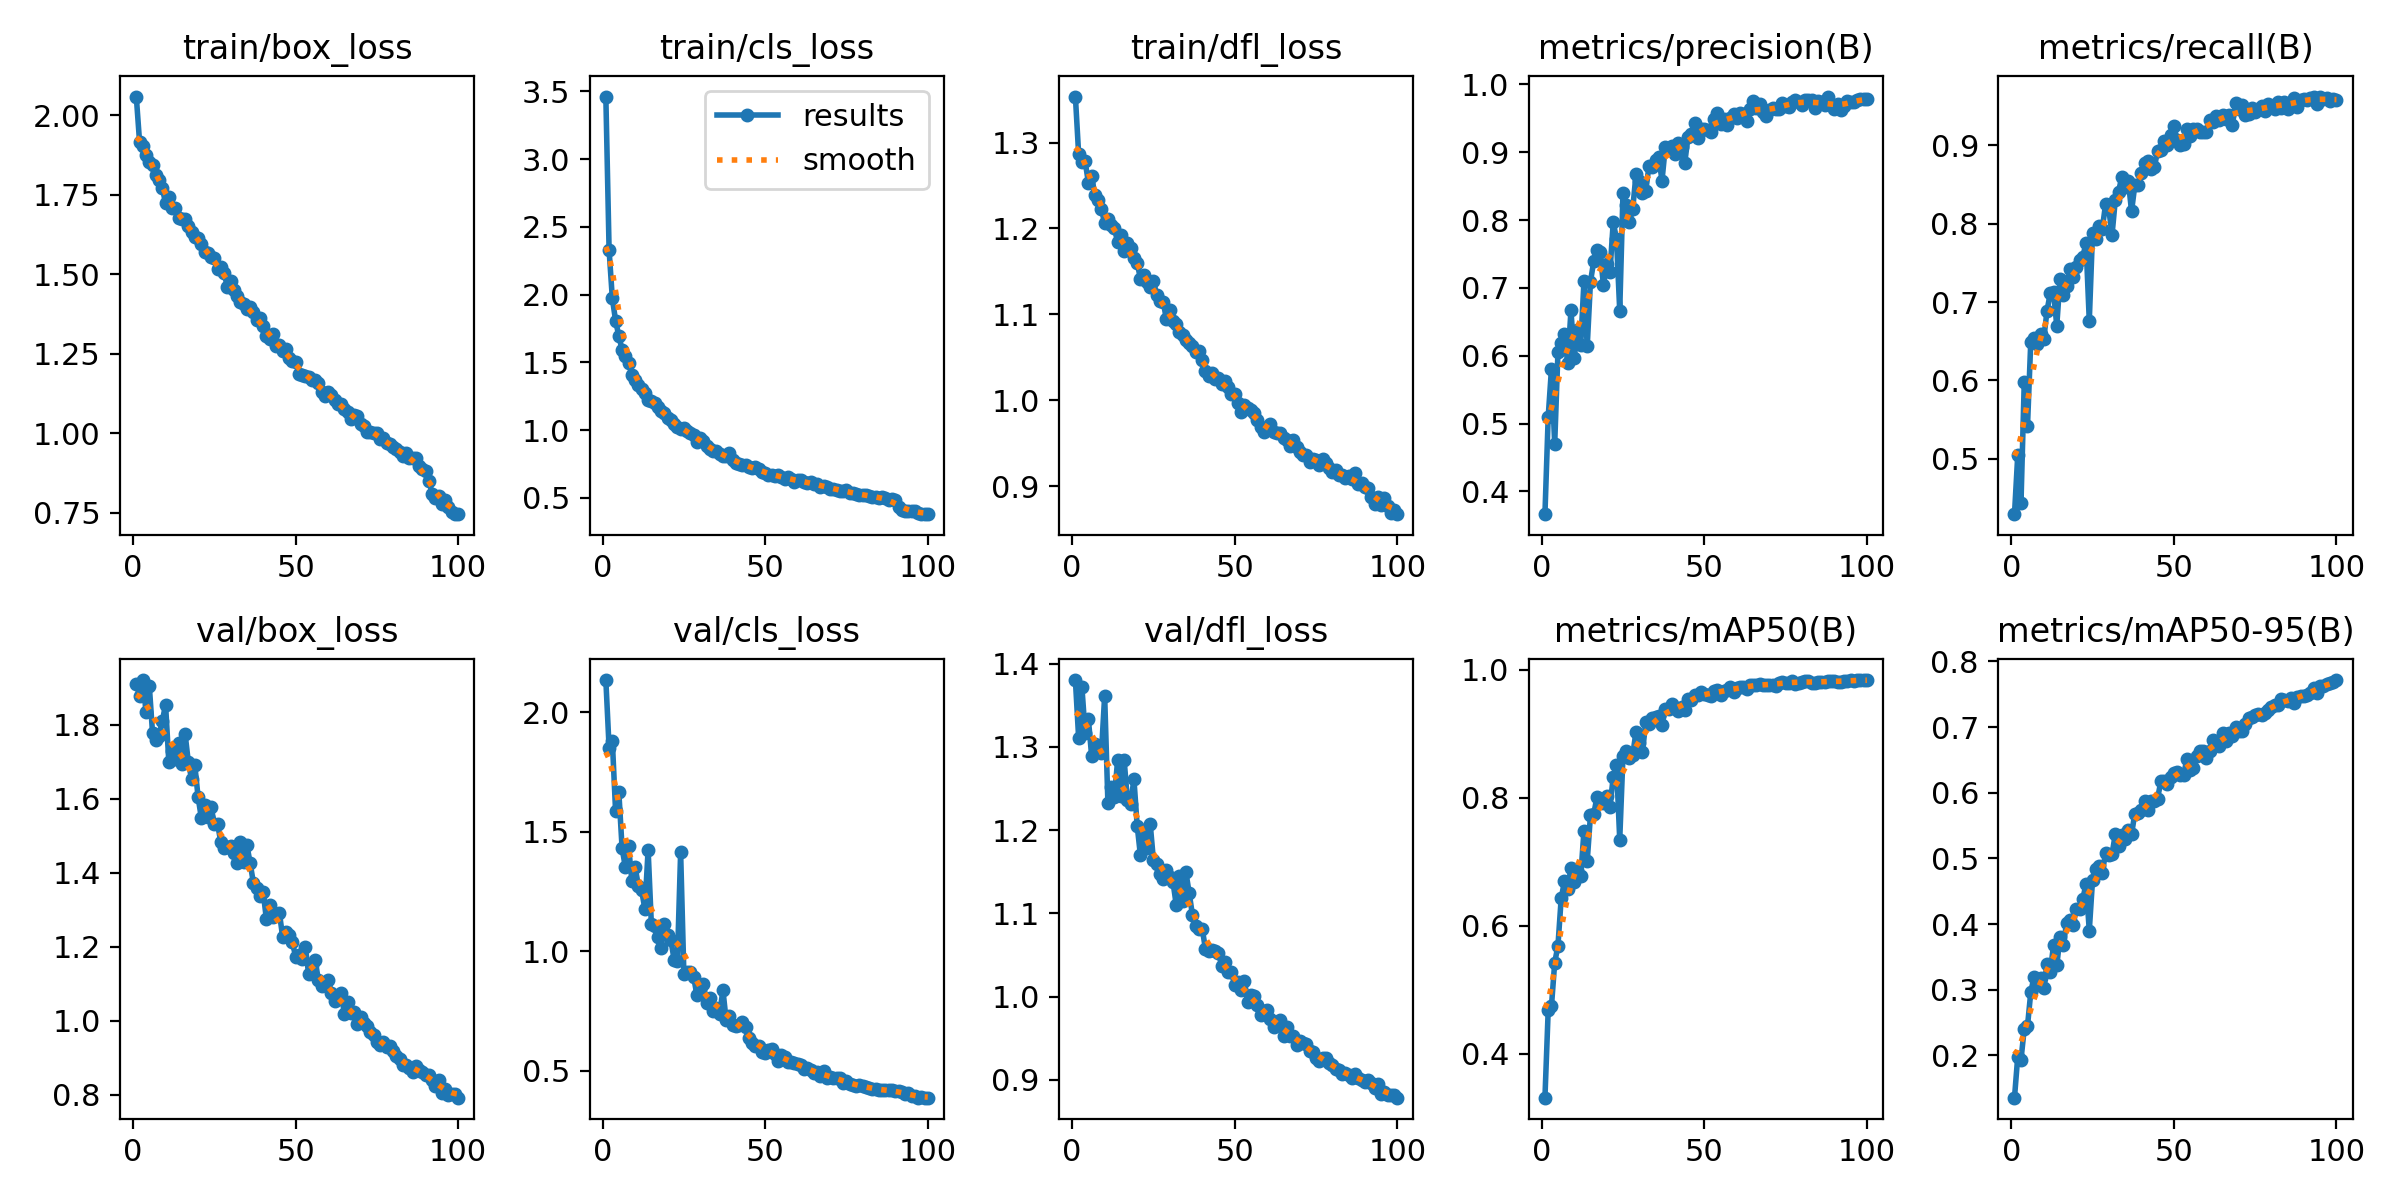

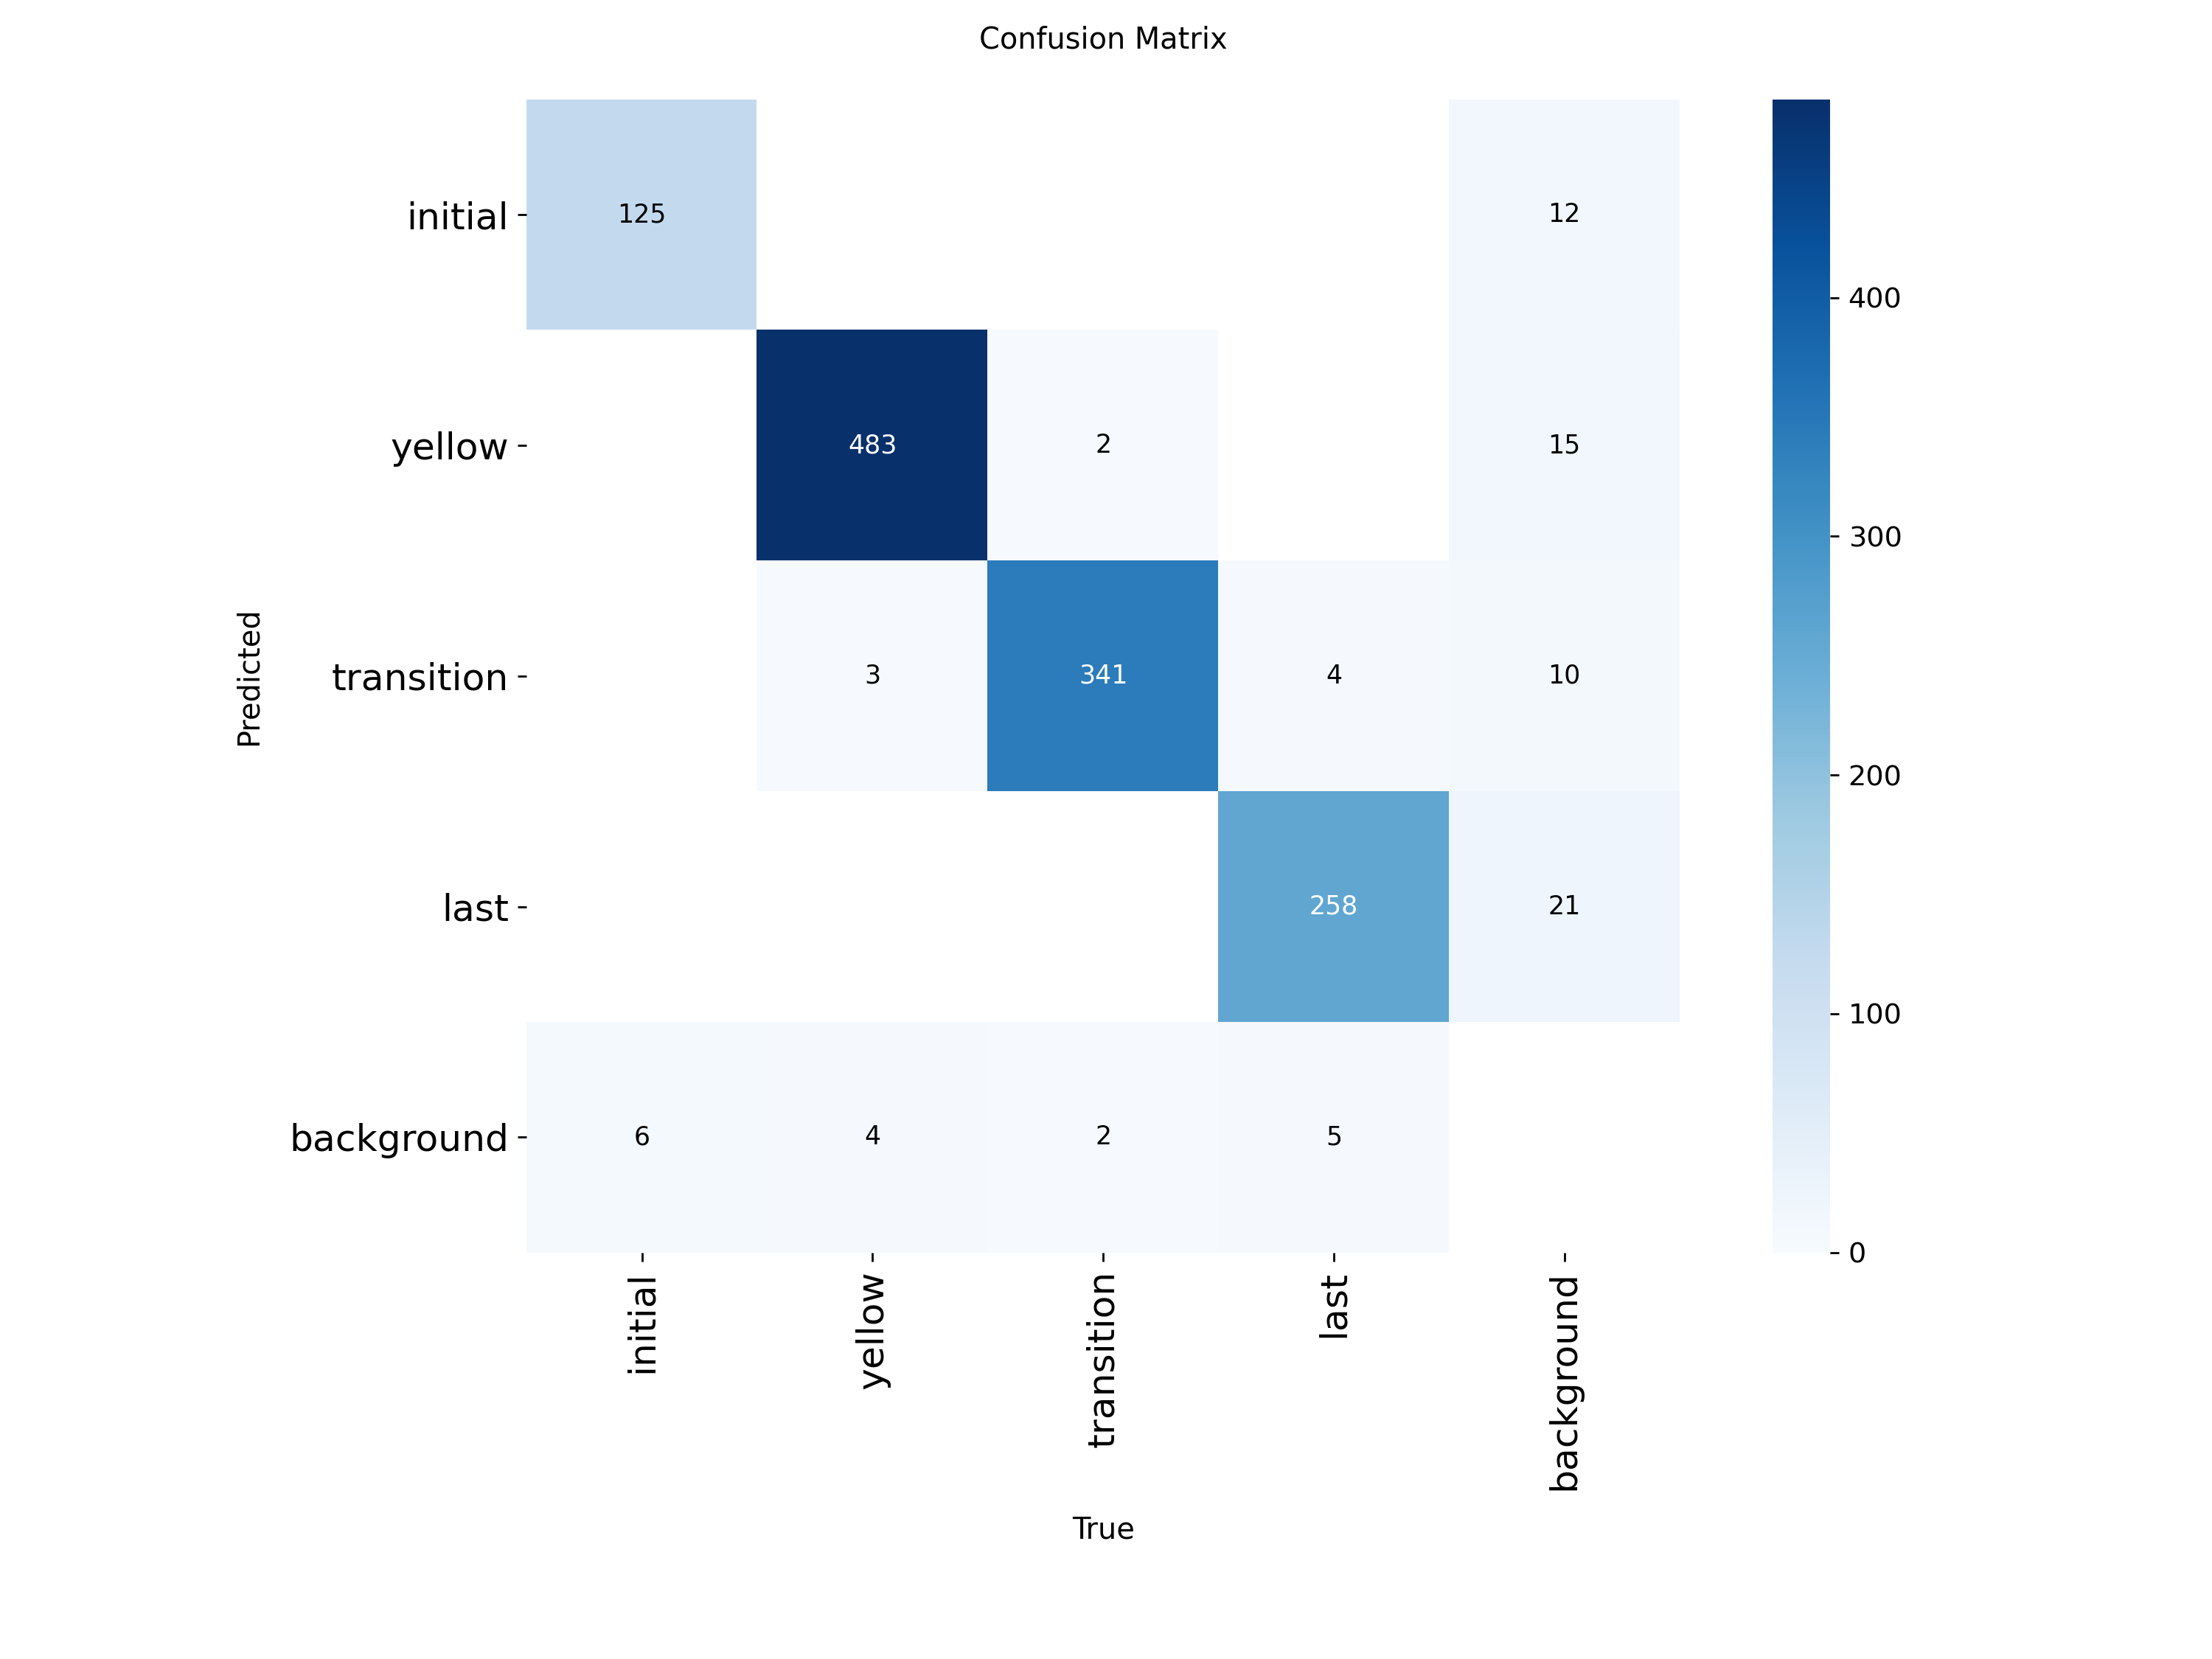

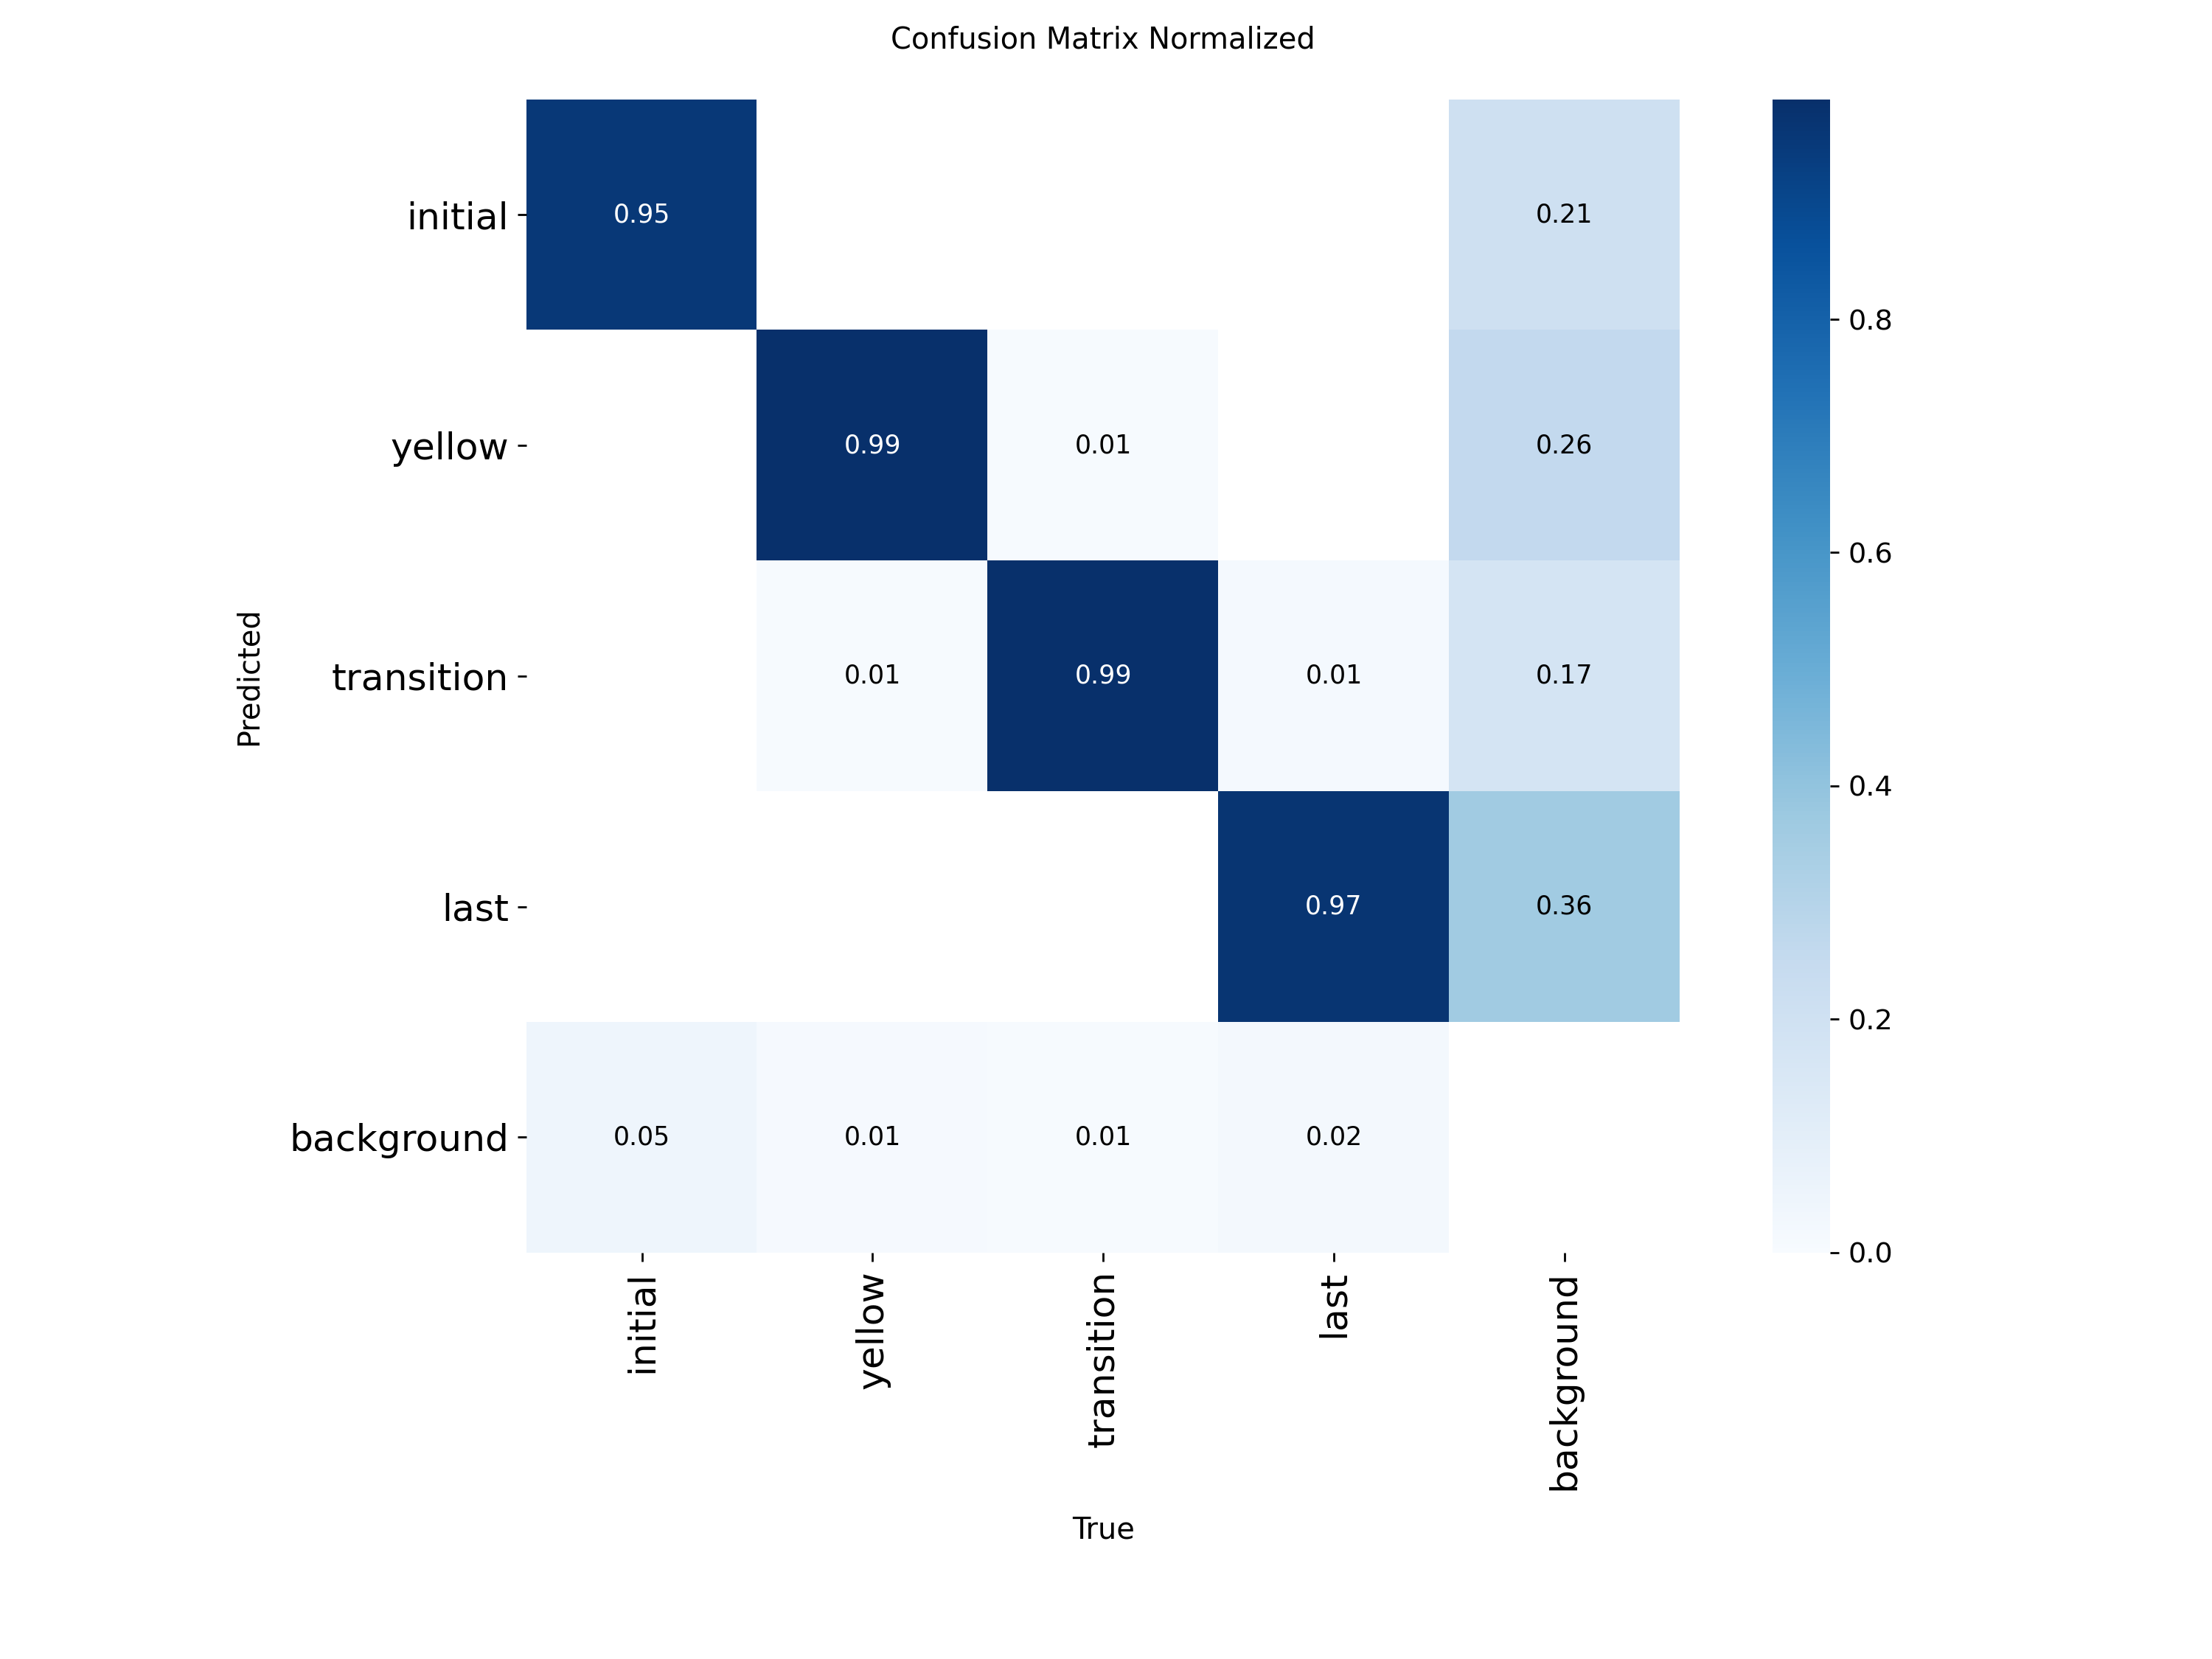

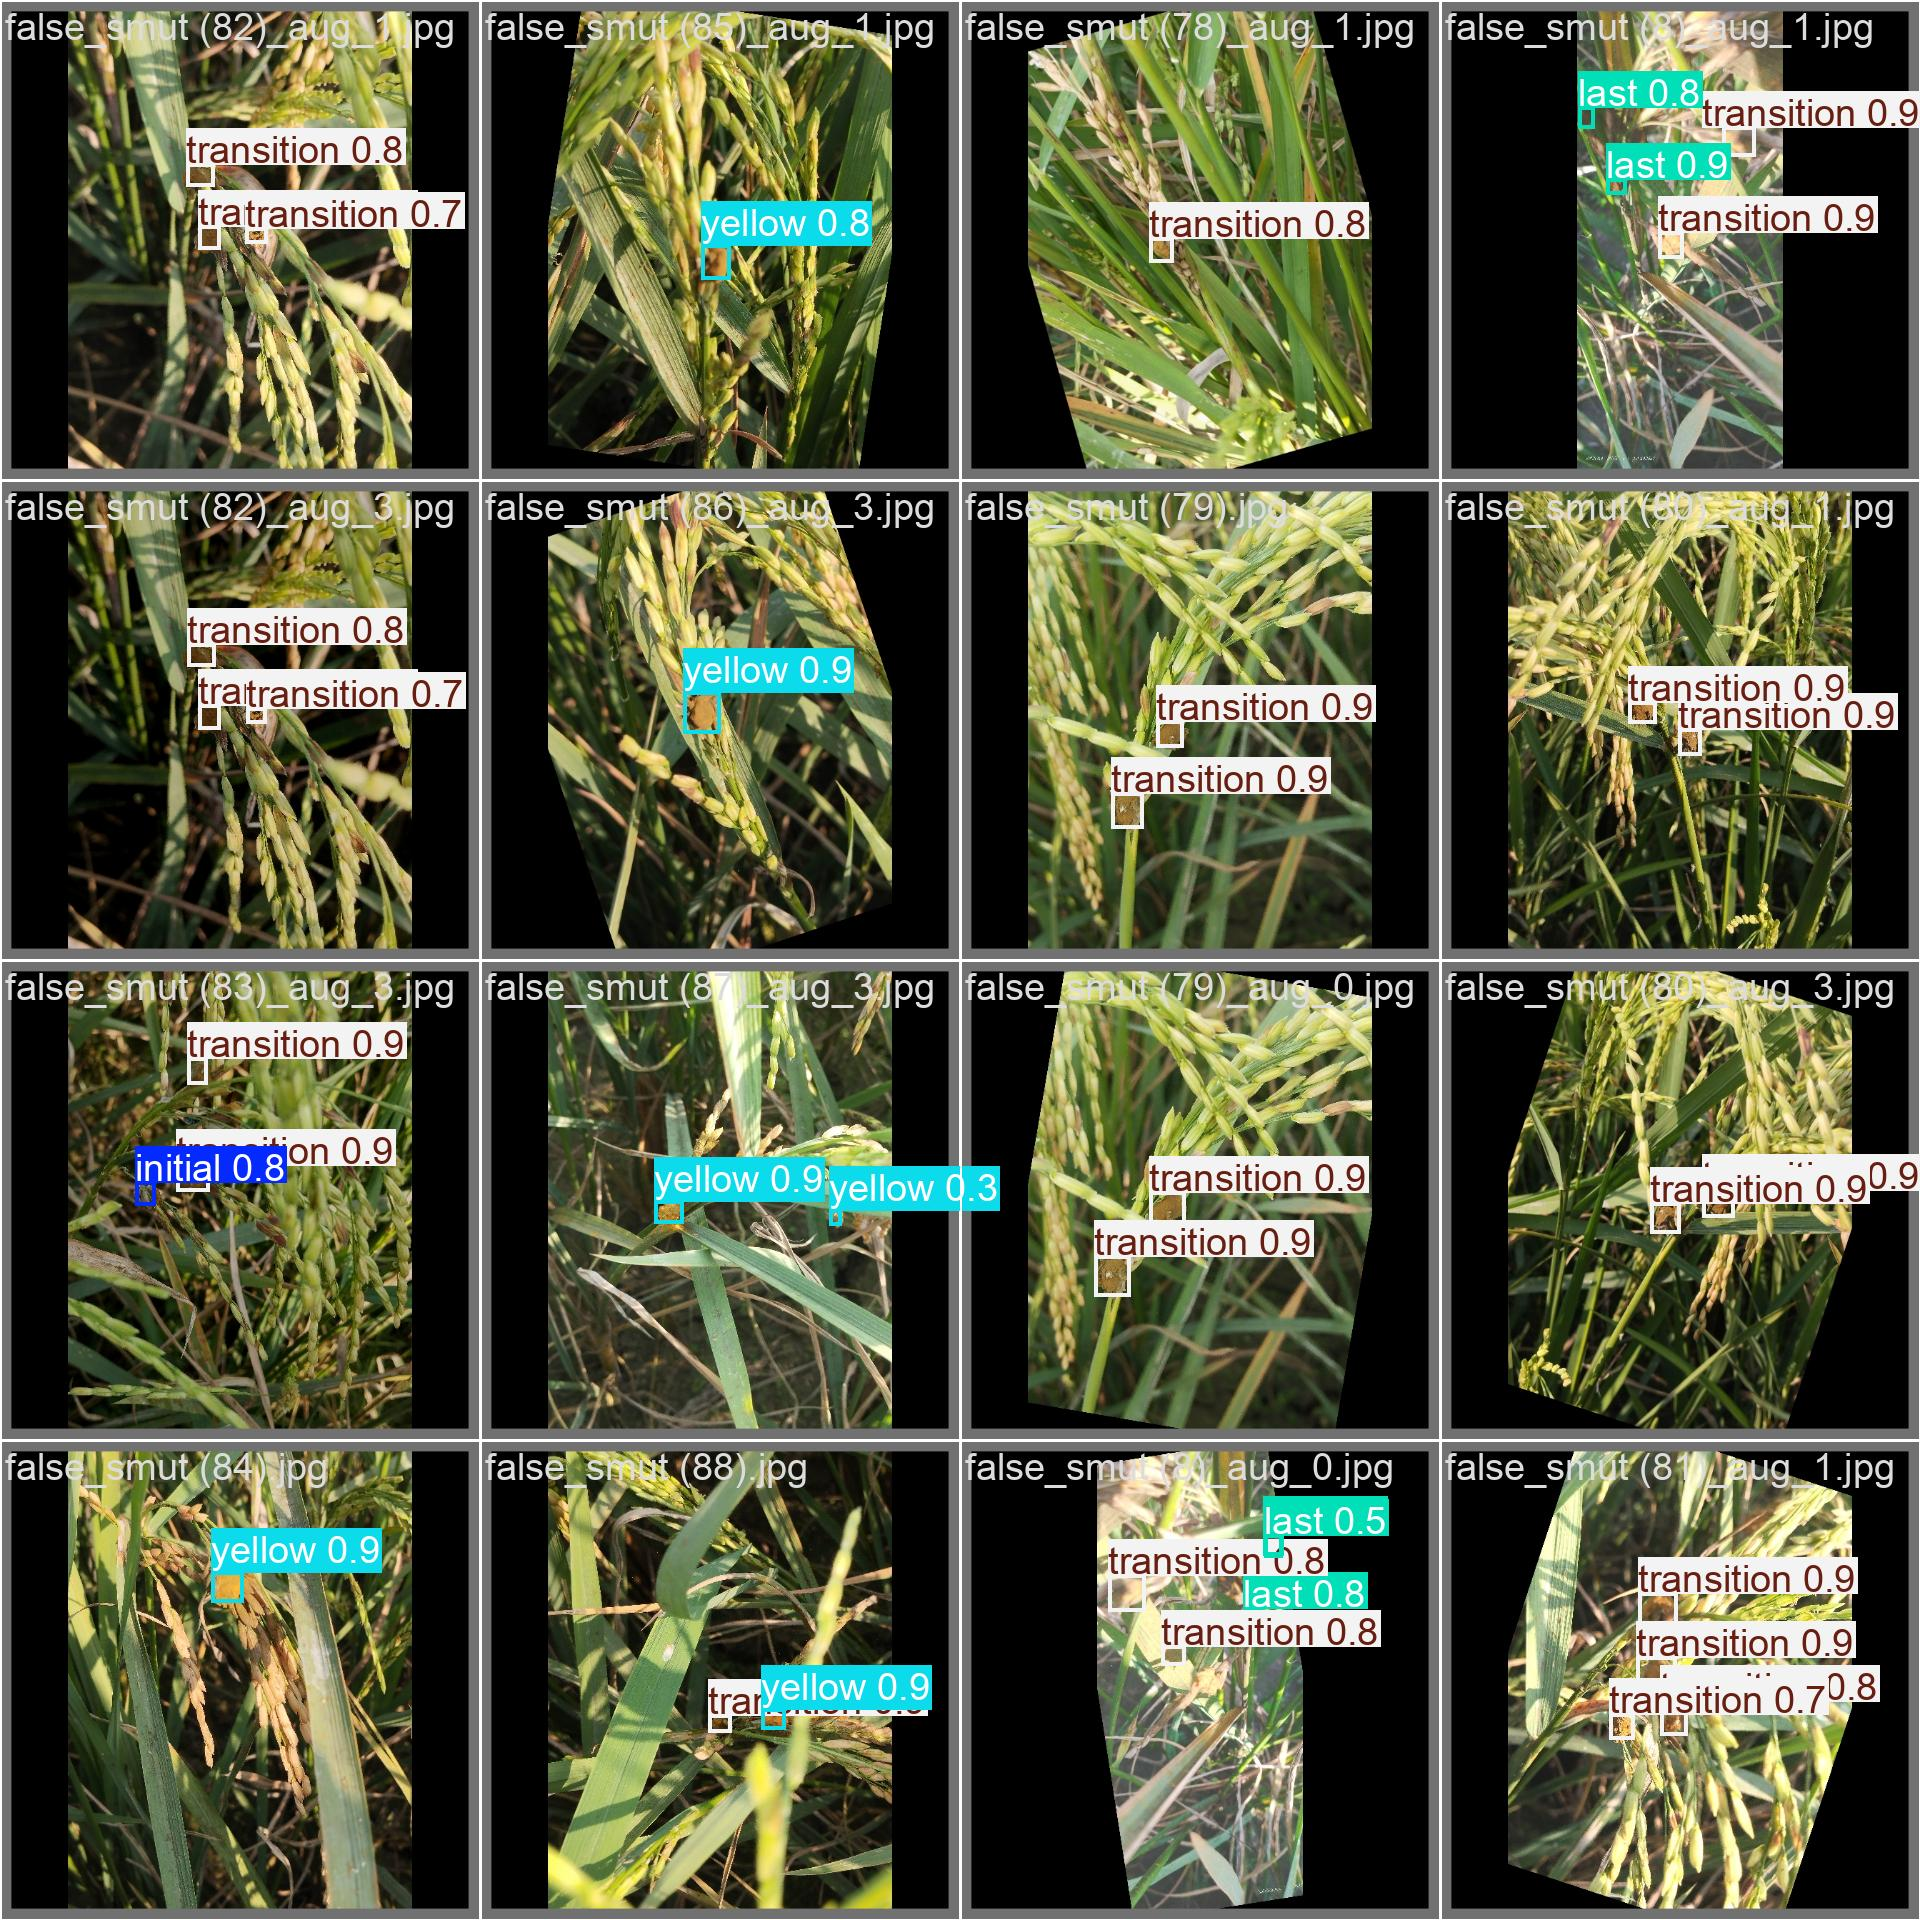

In [7]:
print("="*60)
print("  TRAINING YOLOv8")
print("="*60)

V8_RUN_DIR = f"{BASE_PATH}/runs/yolov8"
os.makedirs(V8_RUN_DIR, exist_ok=True)

model_v8 = YOLO('yolov8n.pt')
model_v8.train(
    data      = DATA_YAML,
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    device    = DEVICE,
    project   = V8_RUN_DIR,
    name      = 'train',
    exist_ok  = True,
    plots     = True,
    save      = True,
    val       = True,
    patience  = 15,
    save_period = 10,
)

v8_dest = copy_results_to_drive(V8_RUN_DIR, 'yolov8')
v8_metrics = extract_metrics(V8_RUN_DIR, 'YOLOv8')
if v8_metrics:
    SUMMARY.append(v8_metrics)
show_result_images(V8_RUN_DIR, 'YOLOv8')

### YOLOv8 — Predict on Test Images

In [8]:
best_v8 = f"{V8_RUN_DIR}/train/weights/best.pt"
model_v8 = YOLO(best_v8)
model_v8.predict(
    source   = TEST_SOURCE,
    conf     = CONF_THRES,
    save     = True,
    save_txt = True,
    save_conf = True,
    project  = V8_RUN_DIR,
    name     = 'predict',
    exist_ok = True,
)
copy_results_to_drive(f"{V8_RUN_DIR}/predict", 'yolov8/predict')
print("✅ YOLOv8 predictions saved.")


image 1/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (1)_aug_1.jpg: 640x640 1 yellow, 9.8ms
image 2/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (1)_aug_2.jpg: 640x640 1 yellow, 6.8ms
image 3/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (1)_aug_3.jpg: 640x640 1 yellow, 6.9ms
image 4/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (10).jpg: 640x640 2 initials, 1 yellow, 2 transitions, 7.2ms
image 5/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (10)_aug_0.jpg: 640x640 2 initials, 1 yellow, 2 transitions, 6.8ms
image 6/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (10)_aug_1.jpg: 640x640 2 initials, 1 yellow, 2 transitions, 7.1ms
image 7/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (13)_aug_2.jpg: 640x640 1 yellow, 7.4ms
image 8/20 /kaggle/input/datasets/tamimresearch/rice

--- 
# 2️⃣  YOLOv10 Training


  TRAINING YOLOv10
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_comparison/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

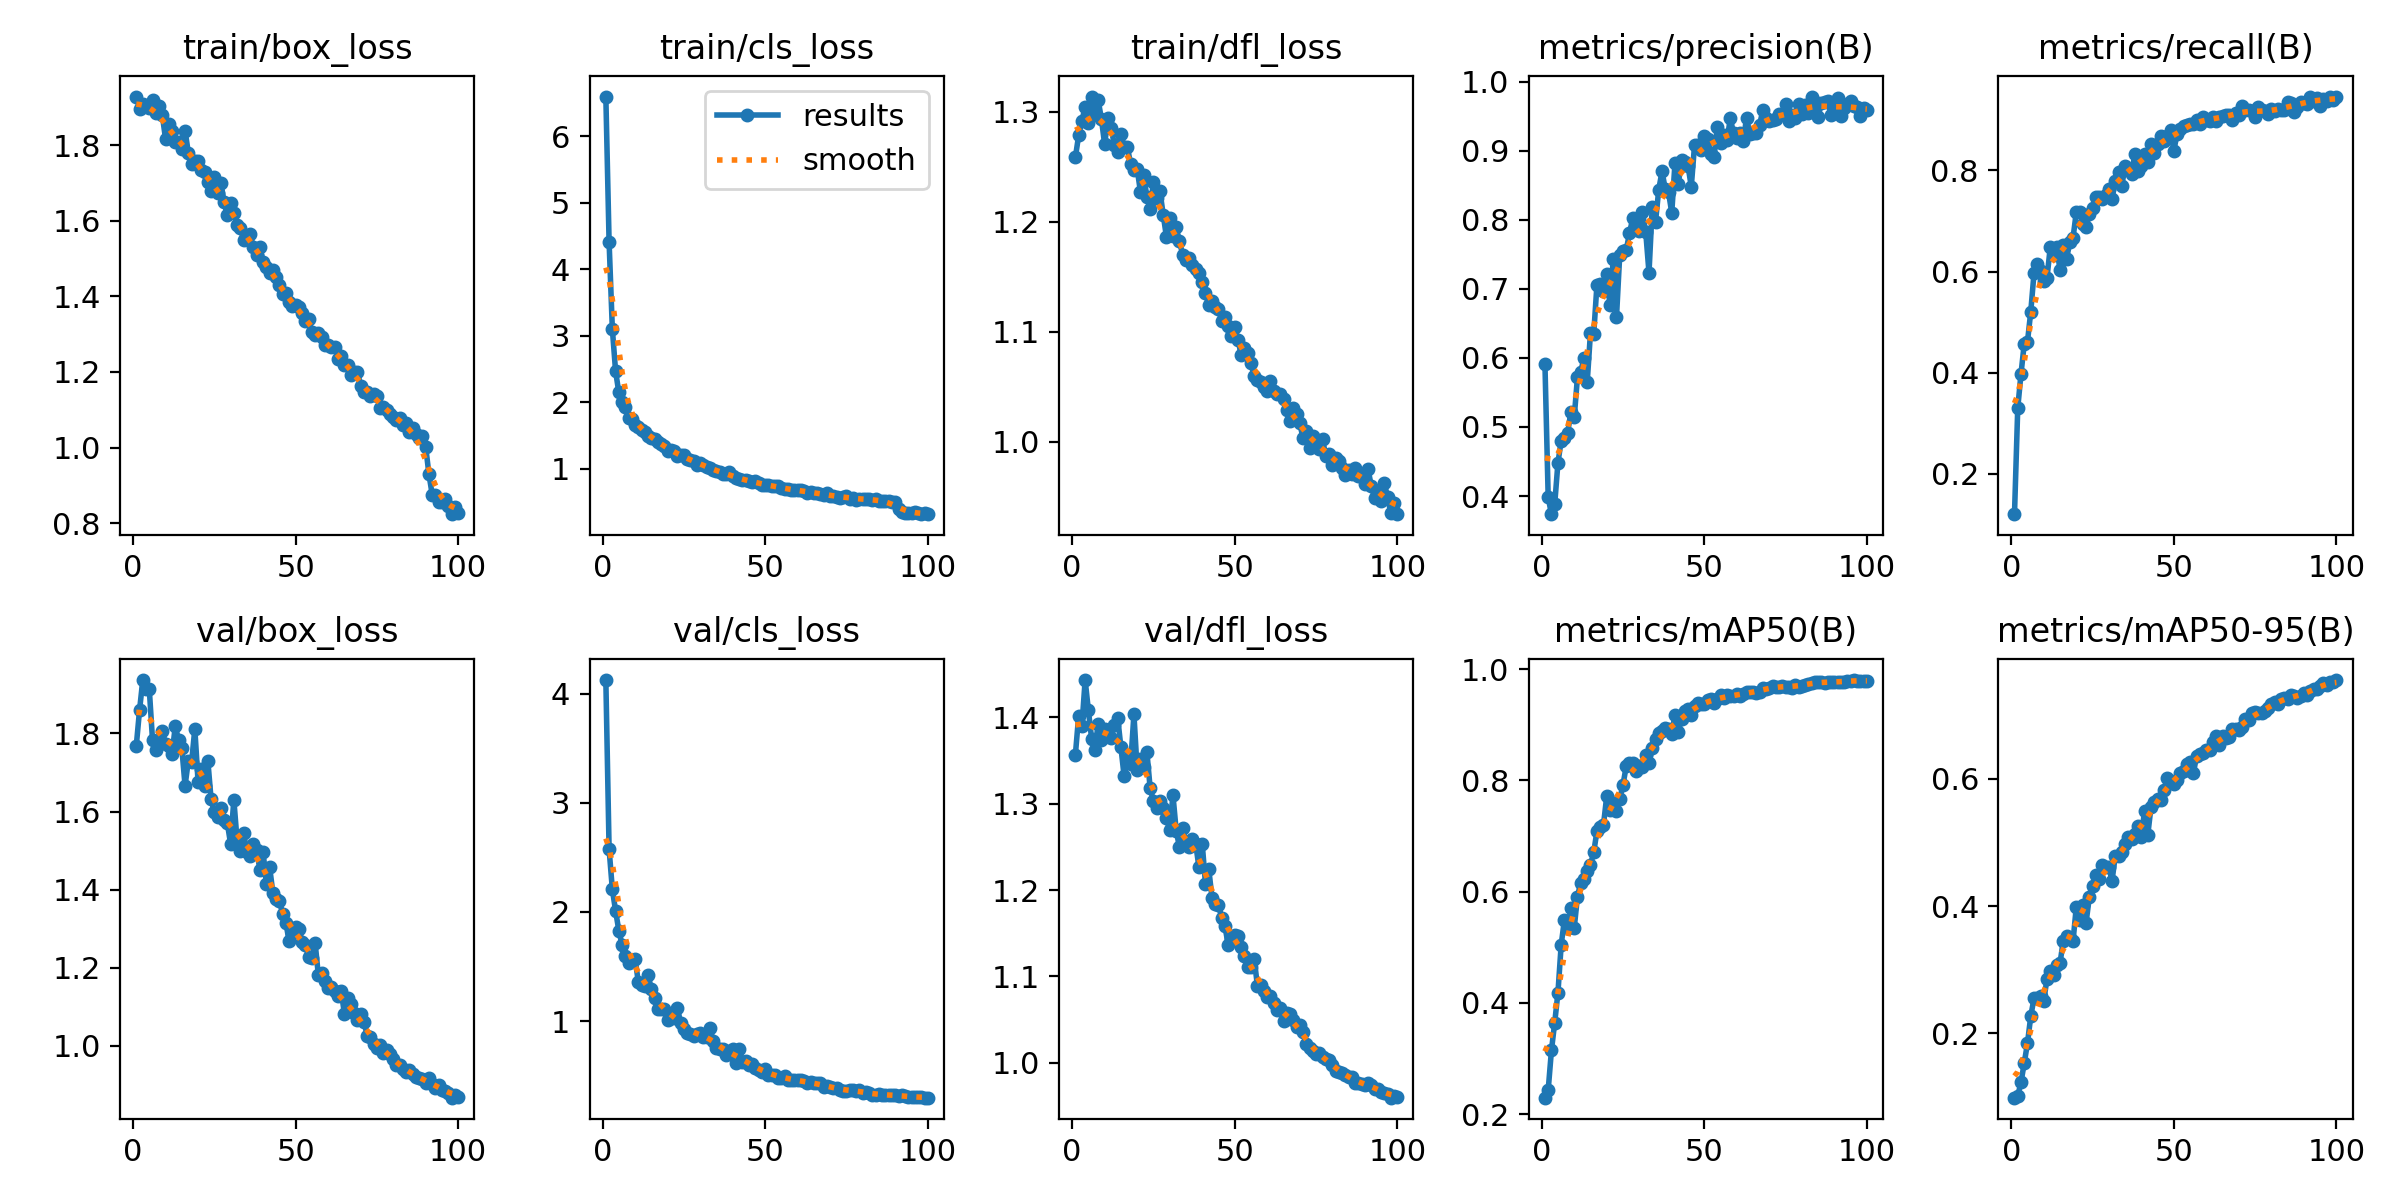

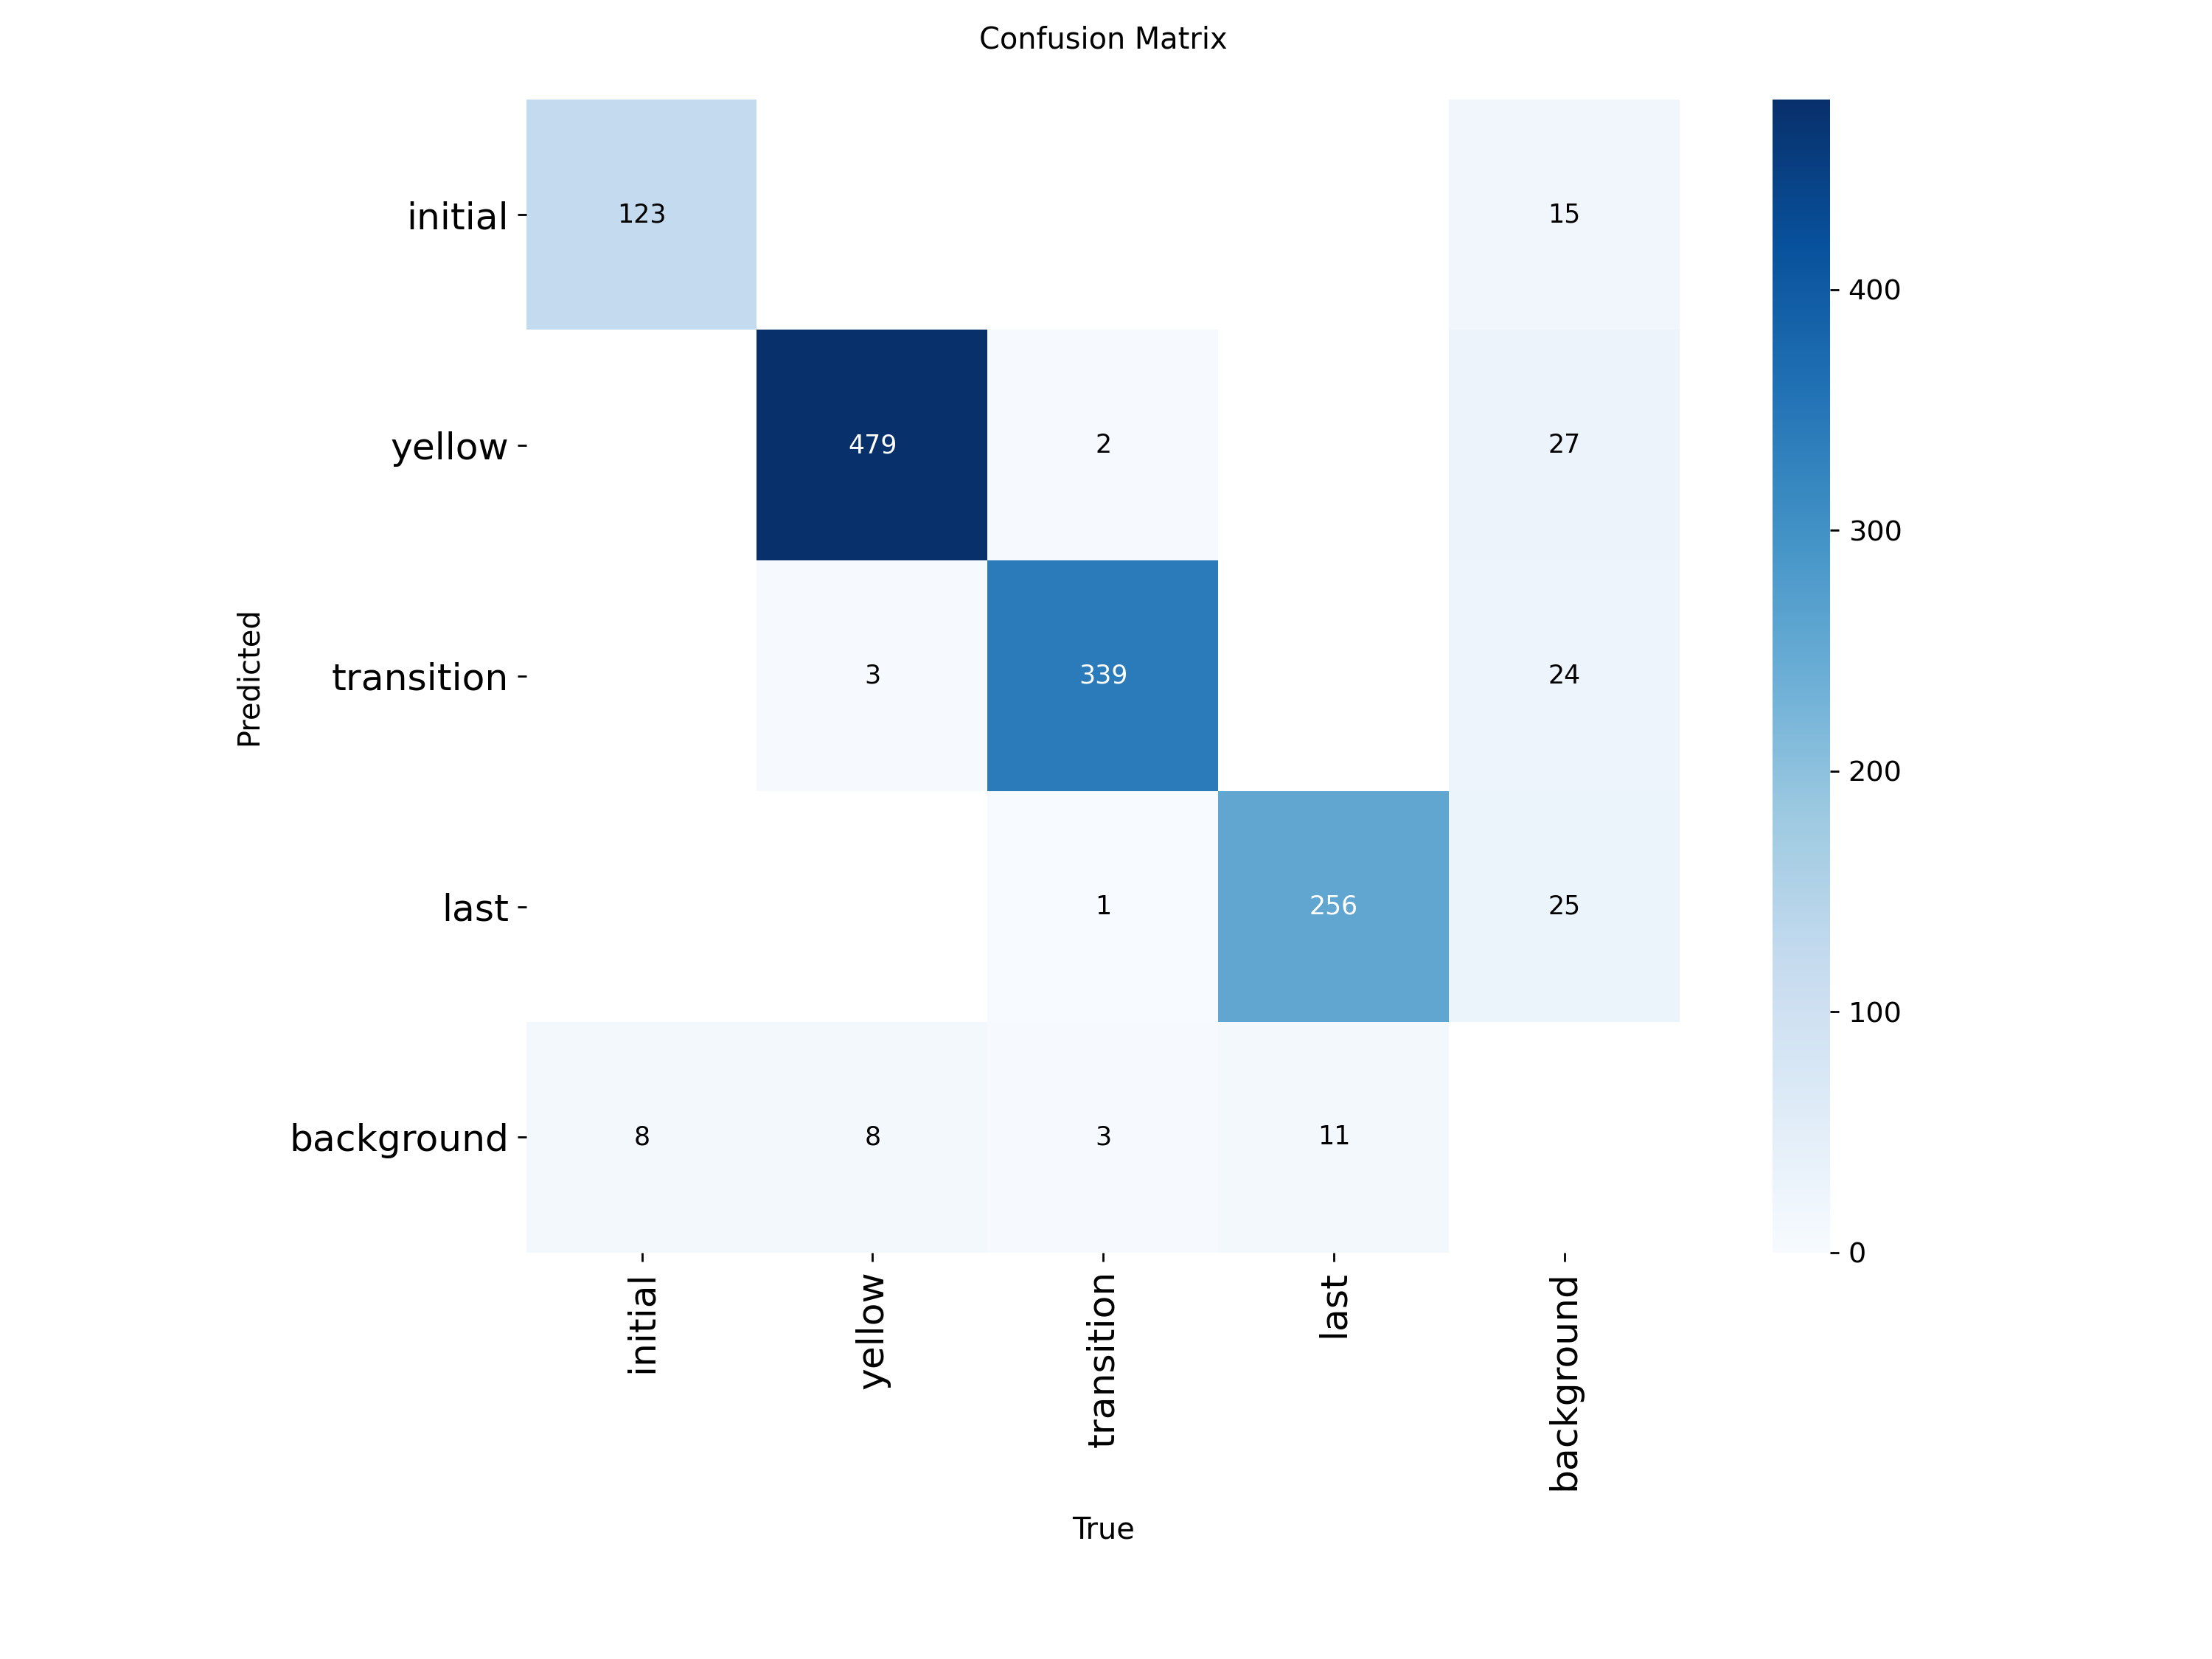

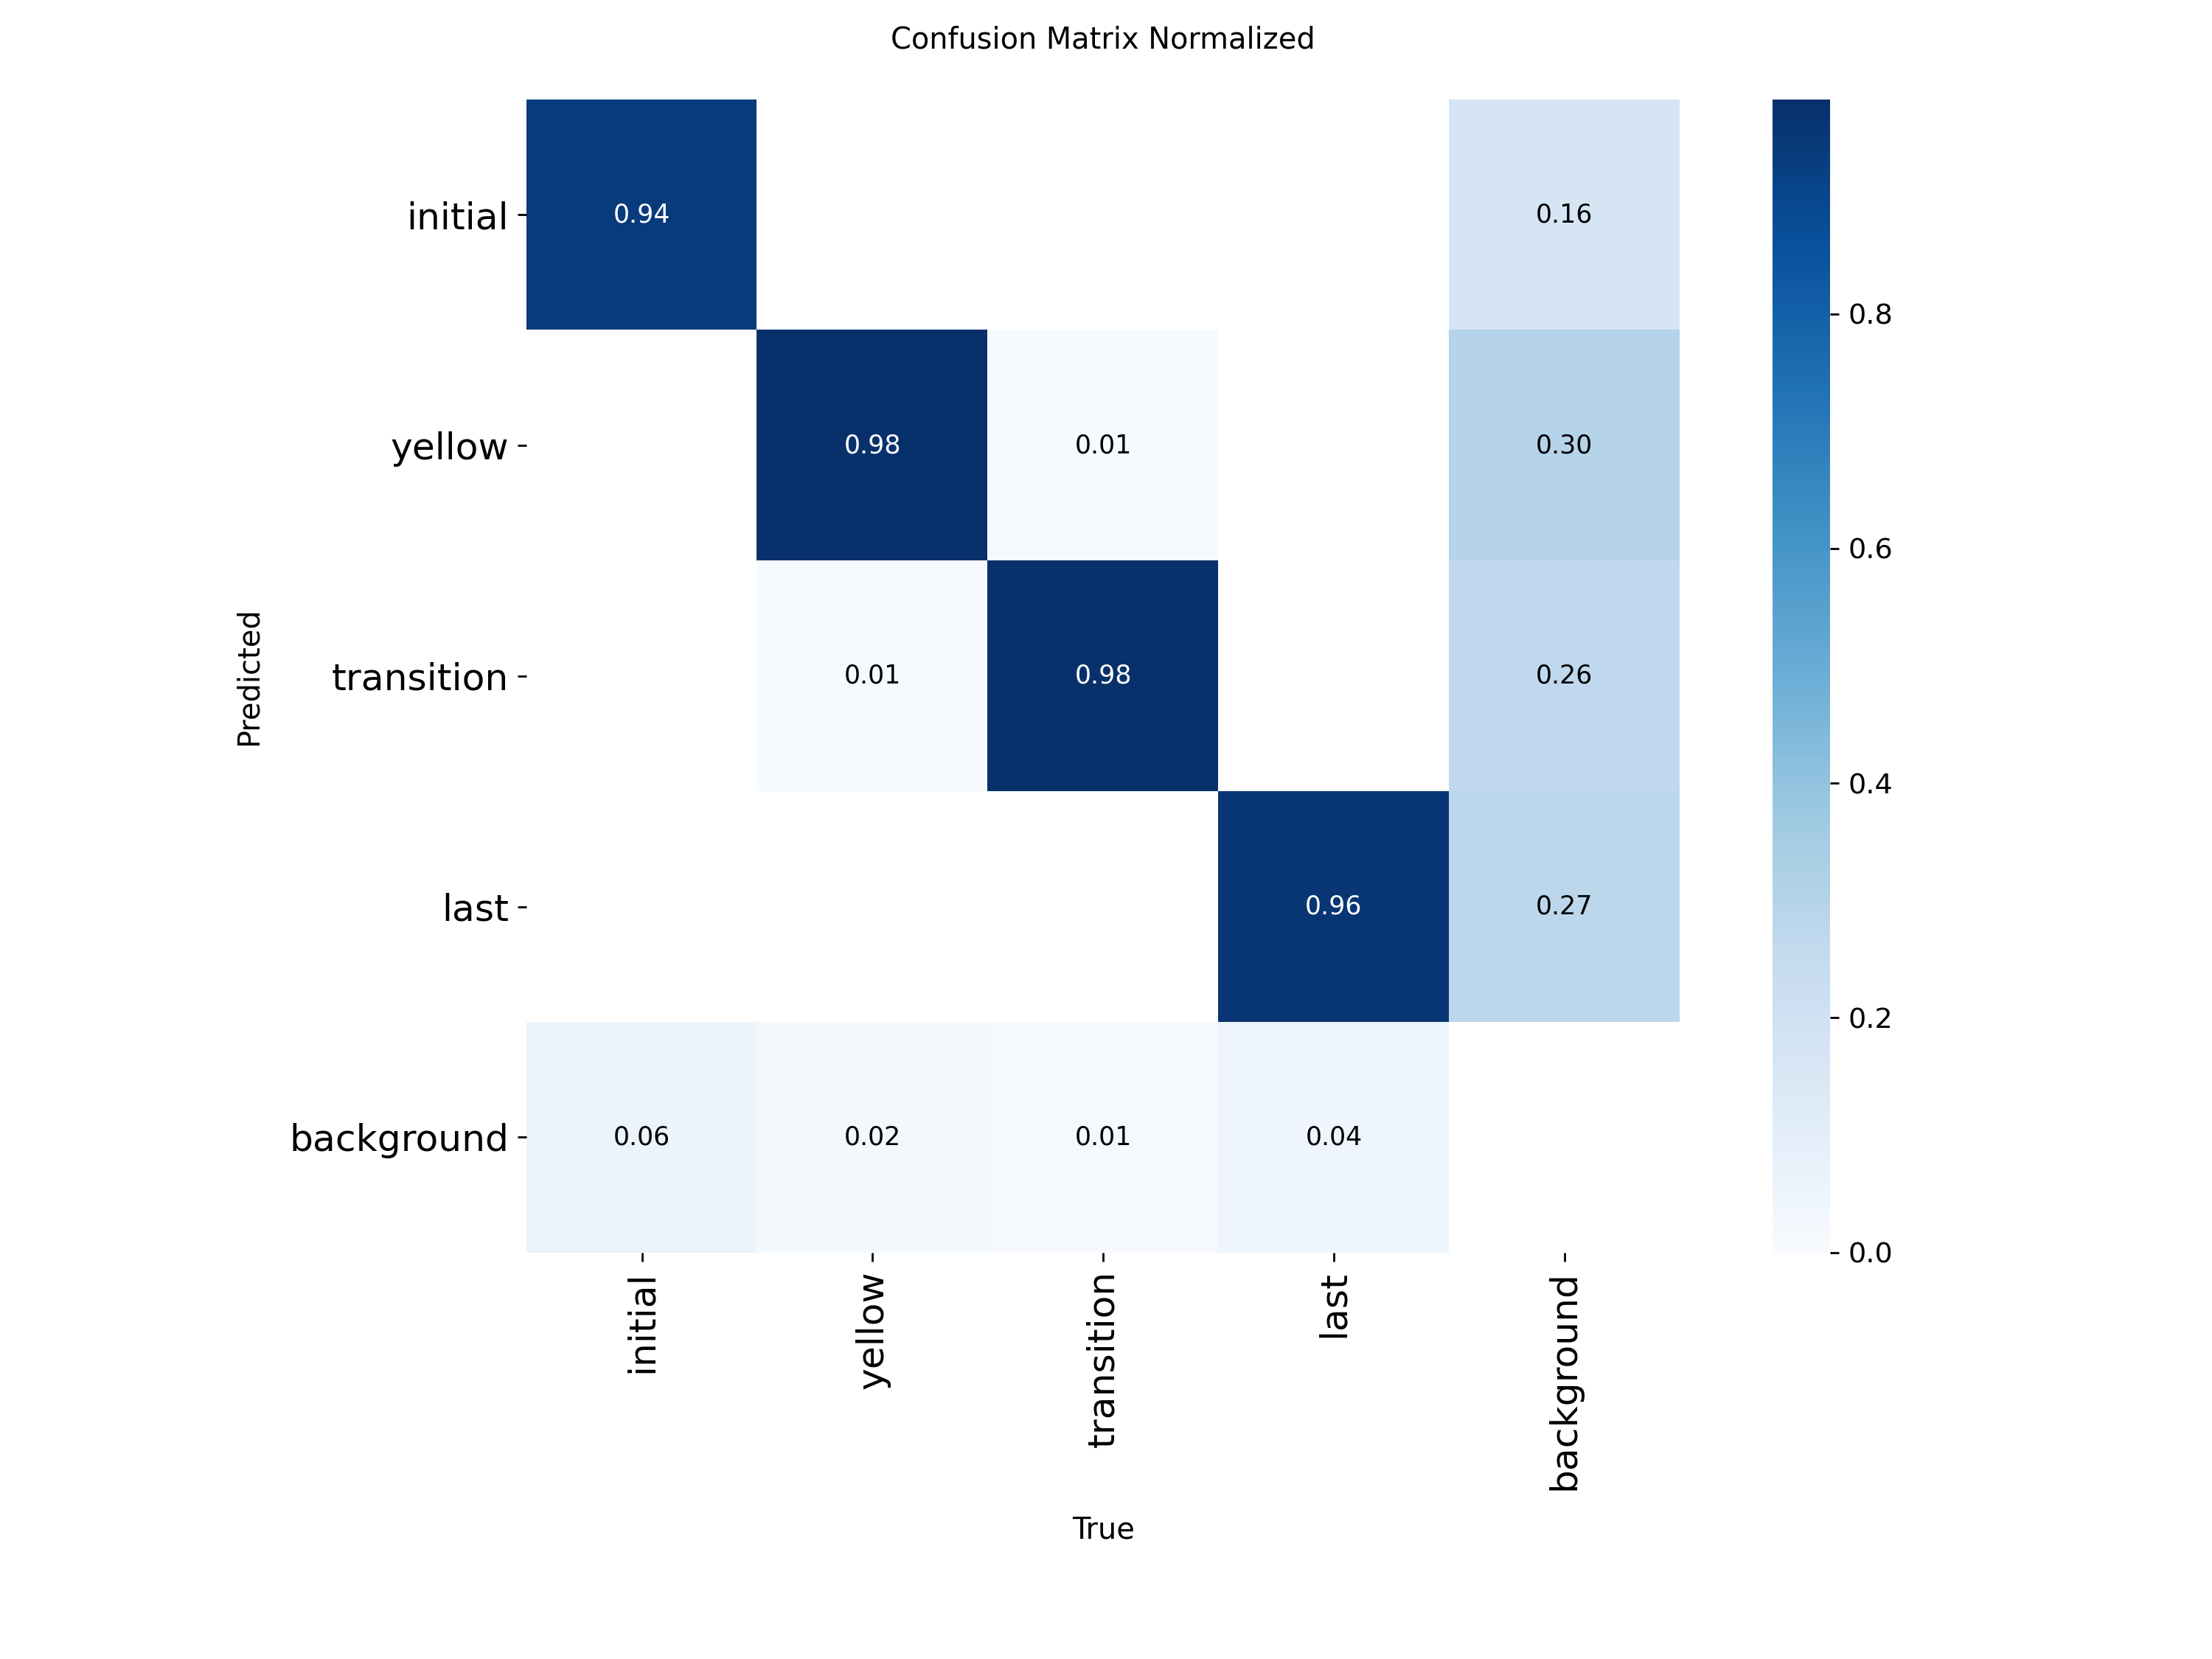

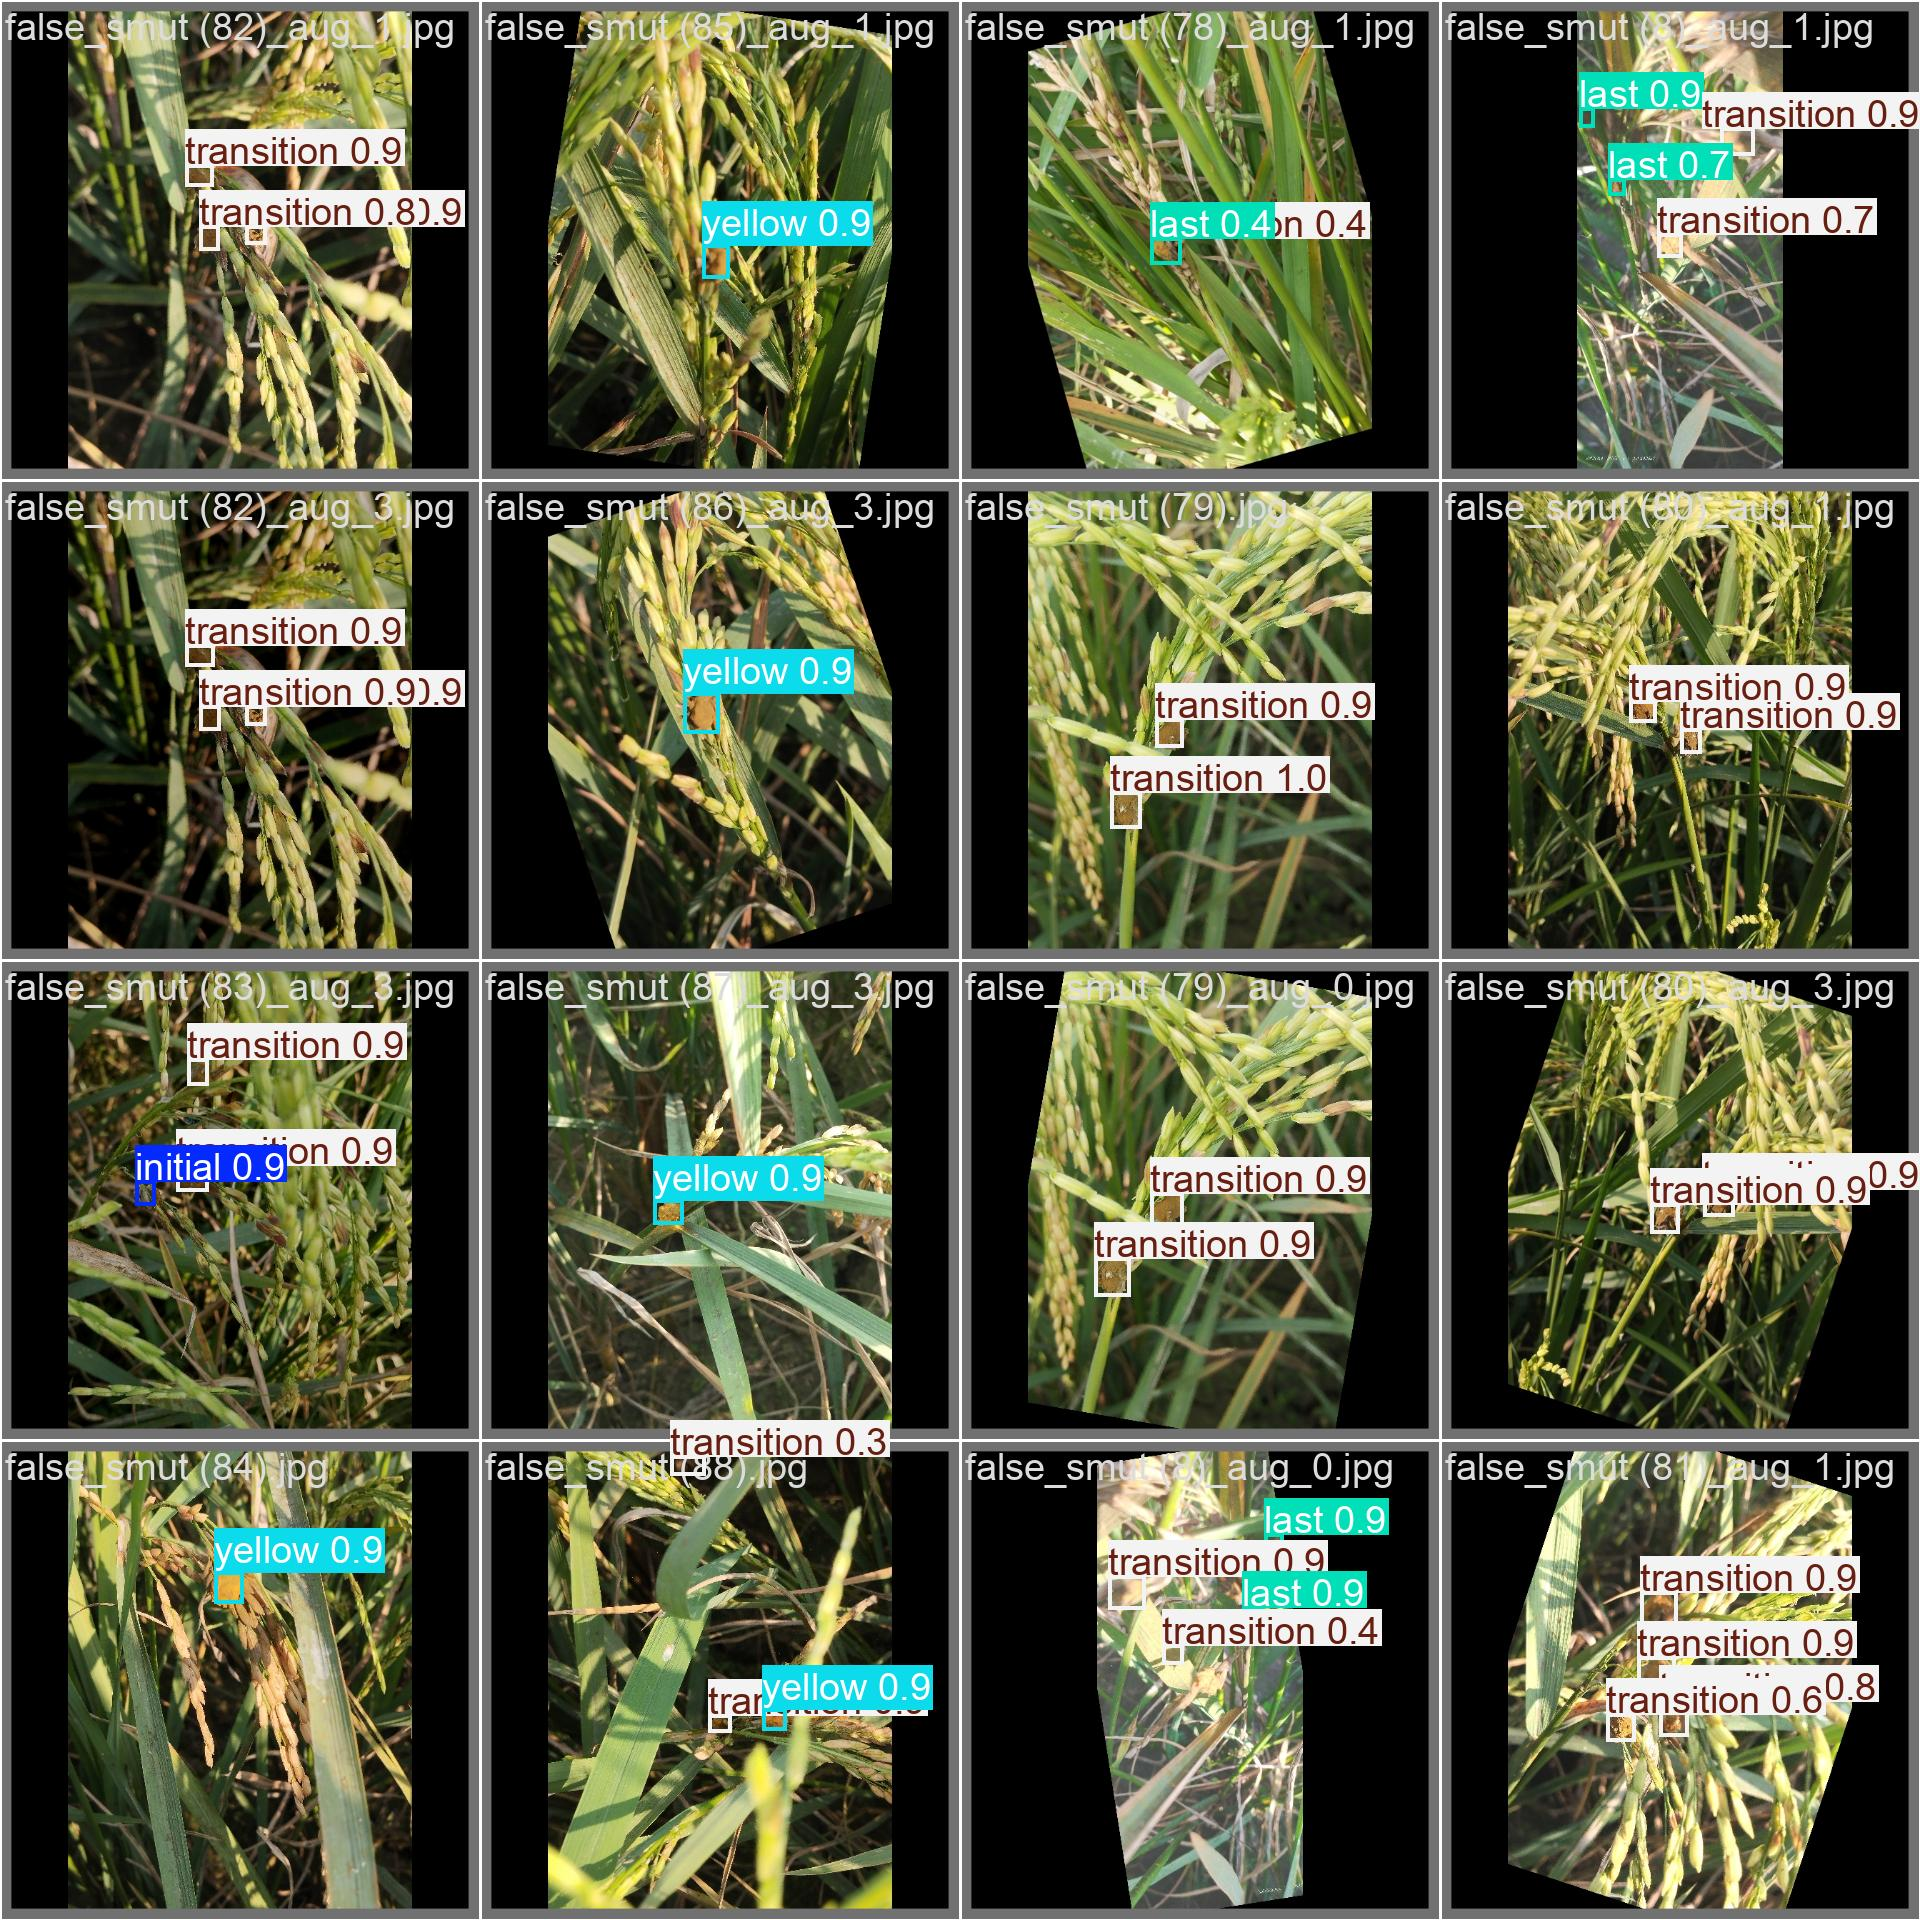

In [9]:
print("="*60)
print("  TRAINING YOLOv10")
print("="*60)

V10_RUN_DIR = f"{BASE_PATH}/runs/yolov10"
os.makedirs(V10_RUN_DIR, exist_ok=True)

model_v10 = YOLO('yolov10n.pt')
model_v10.train(
    data      = DATA_YAML,
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    device    = DEVICE,
    project   = V10_RUN_DIR,
    name      = 'train',
    exist_ok  = True,
    plots     = True,
    save      = True,
    val       = True,
    patience  = 15,
    save_period = 10,
)

v10_dest = copy_results_to_drive(V10_RUN_DIR, 'yolov10')
v10_metrics = extract_metrics(V10_RUN_DIR, 'YOLOv10')
if v10_metrics:
    SUMMARY.append(v10_metrics)
show_result_images(V10_RUN_DIR, 'YOLOv10')

### YOLOv10 — Predict on Test Images

In [10]:
best_v10 = f"{V10_RUN_DIR}/train/weights/best.pt"
model_v10 = YOLO(best_v10)
model_v10.predict(
    source    = TEST_SOURCE,
    conf      = CONF_THRES,
    save      = True,
    save_txt  = True,
    save_conf = True,
    project   = V10_RUN_DIR,
    name      = 'predict',
    exist_ok  = True,
)
copy_results_to_drive(f"{V10_RUN_DIR}/predict", 'yolov10/predict')
print("✅ YOLOv10 predictions saved.")


image 1/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (1)_aug_1.jpg: 640x640 1 yellow, 7.5ms
image 2/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (1)_aug_2.jpg: 640x640 2 yellows, 8.5ms
image 3/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (1)_aug_3.jpg: 640x640 1 yellow, 7.7ms
image 4/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (10).jpg: 640x640 2 initials, 1 yellow, 2 transitions, 7.9ms
image 5/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (10)_aug_0.jpg: 640x640 2 initials, 1 yellow, 2 transitions, 7.4ms
image 6/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (10)_aug_1.jpg: 640x640 2 initials, 1 yellow, 2 transitions, 7.6ms
image 7/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (13)_aug_2.jpg: 640x640 1 yellow, 7.8ms
image 8/20 /kaggle/input/datasets/tamimresearch/ric

--- 
# 3️⃣  YOLOv9 Training


  TRAINING YOLOv9
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_comparison/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=aut

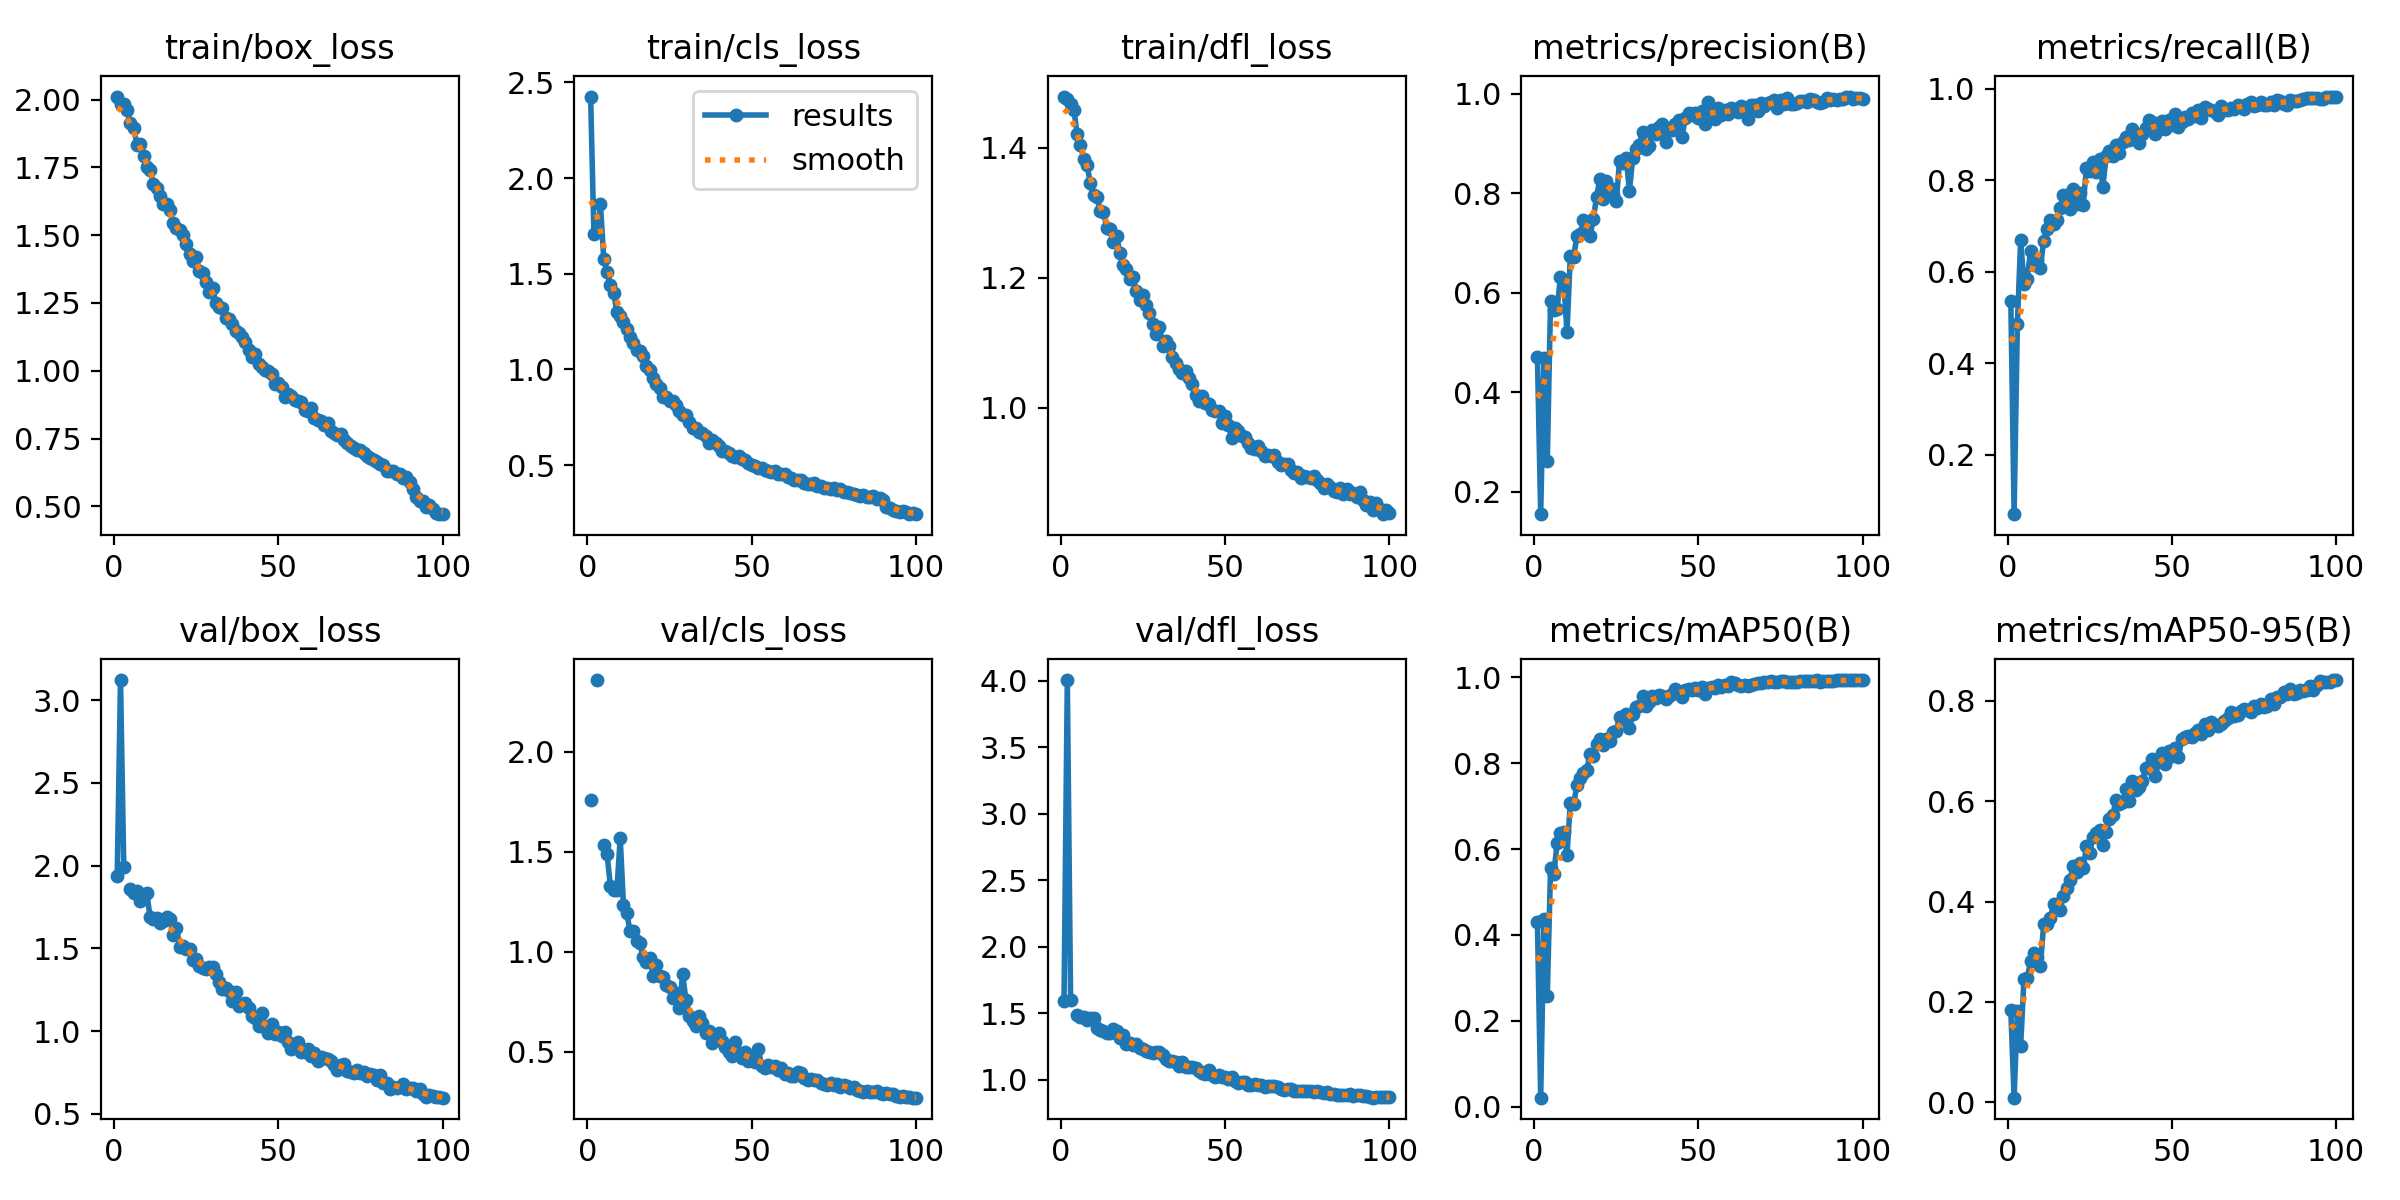

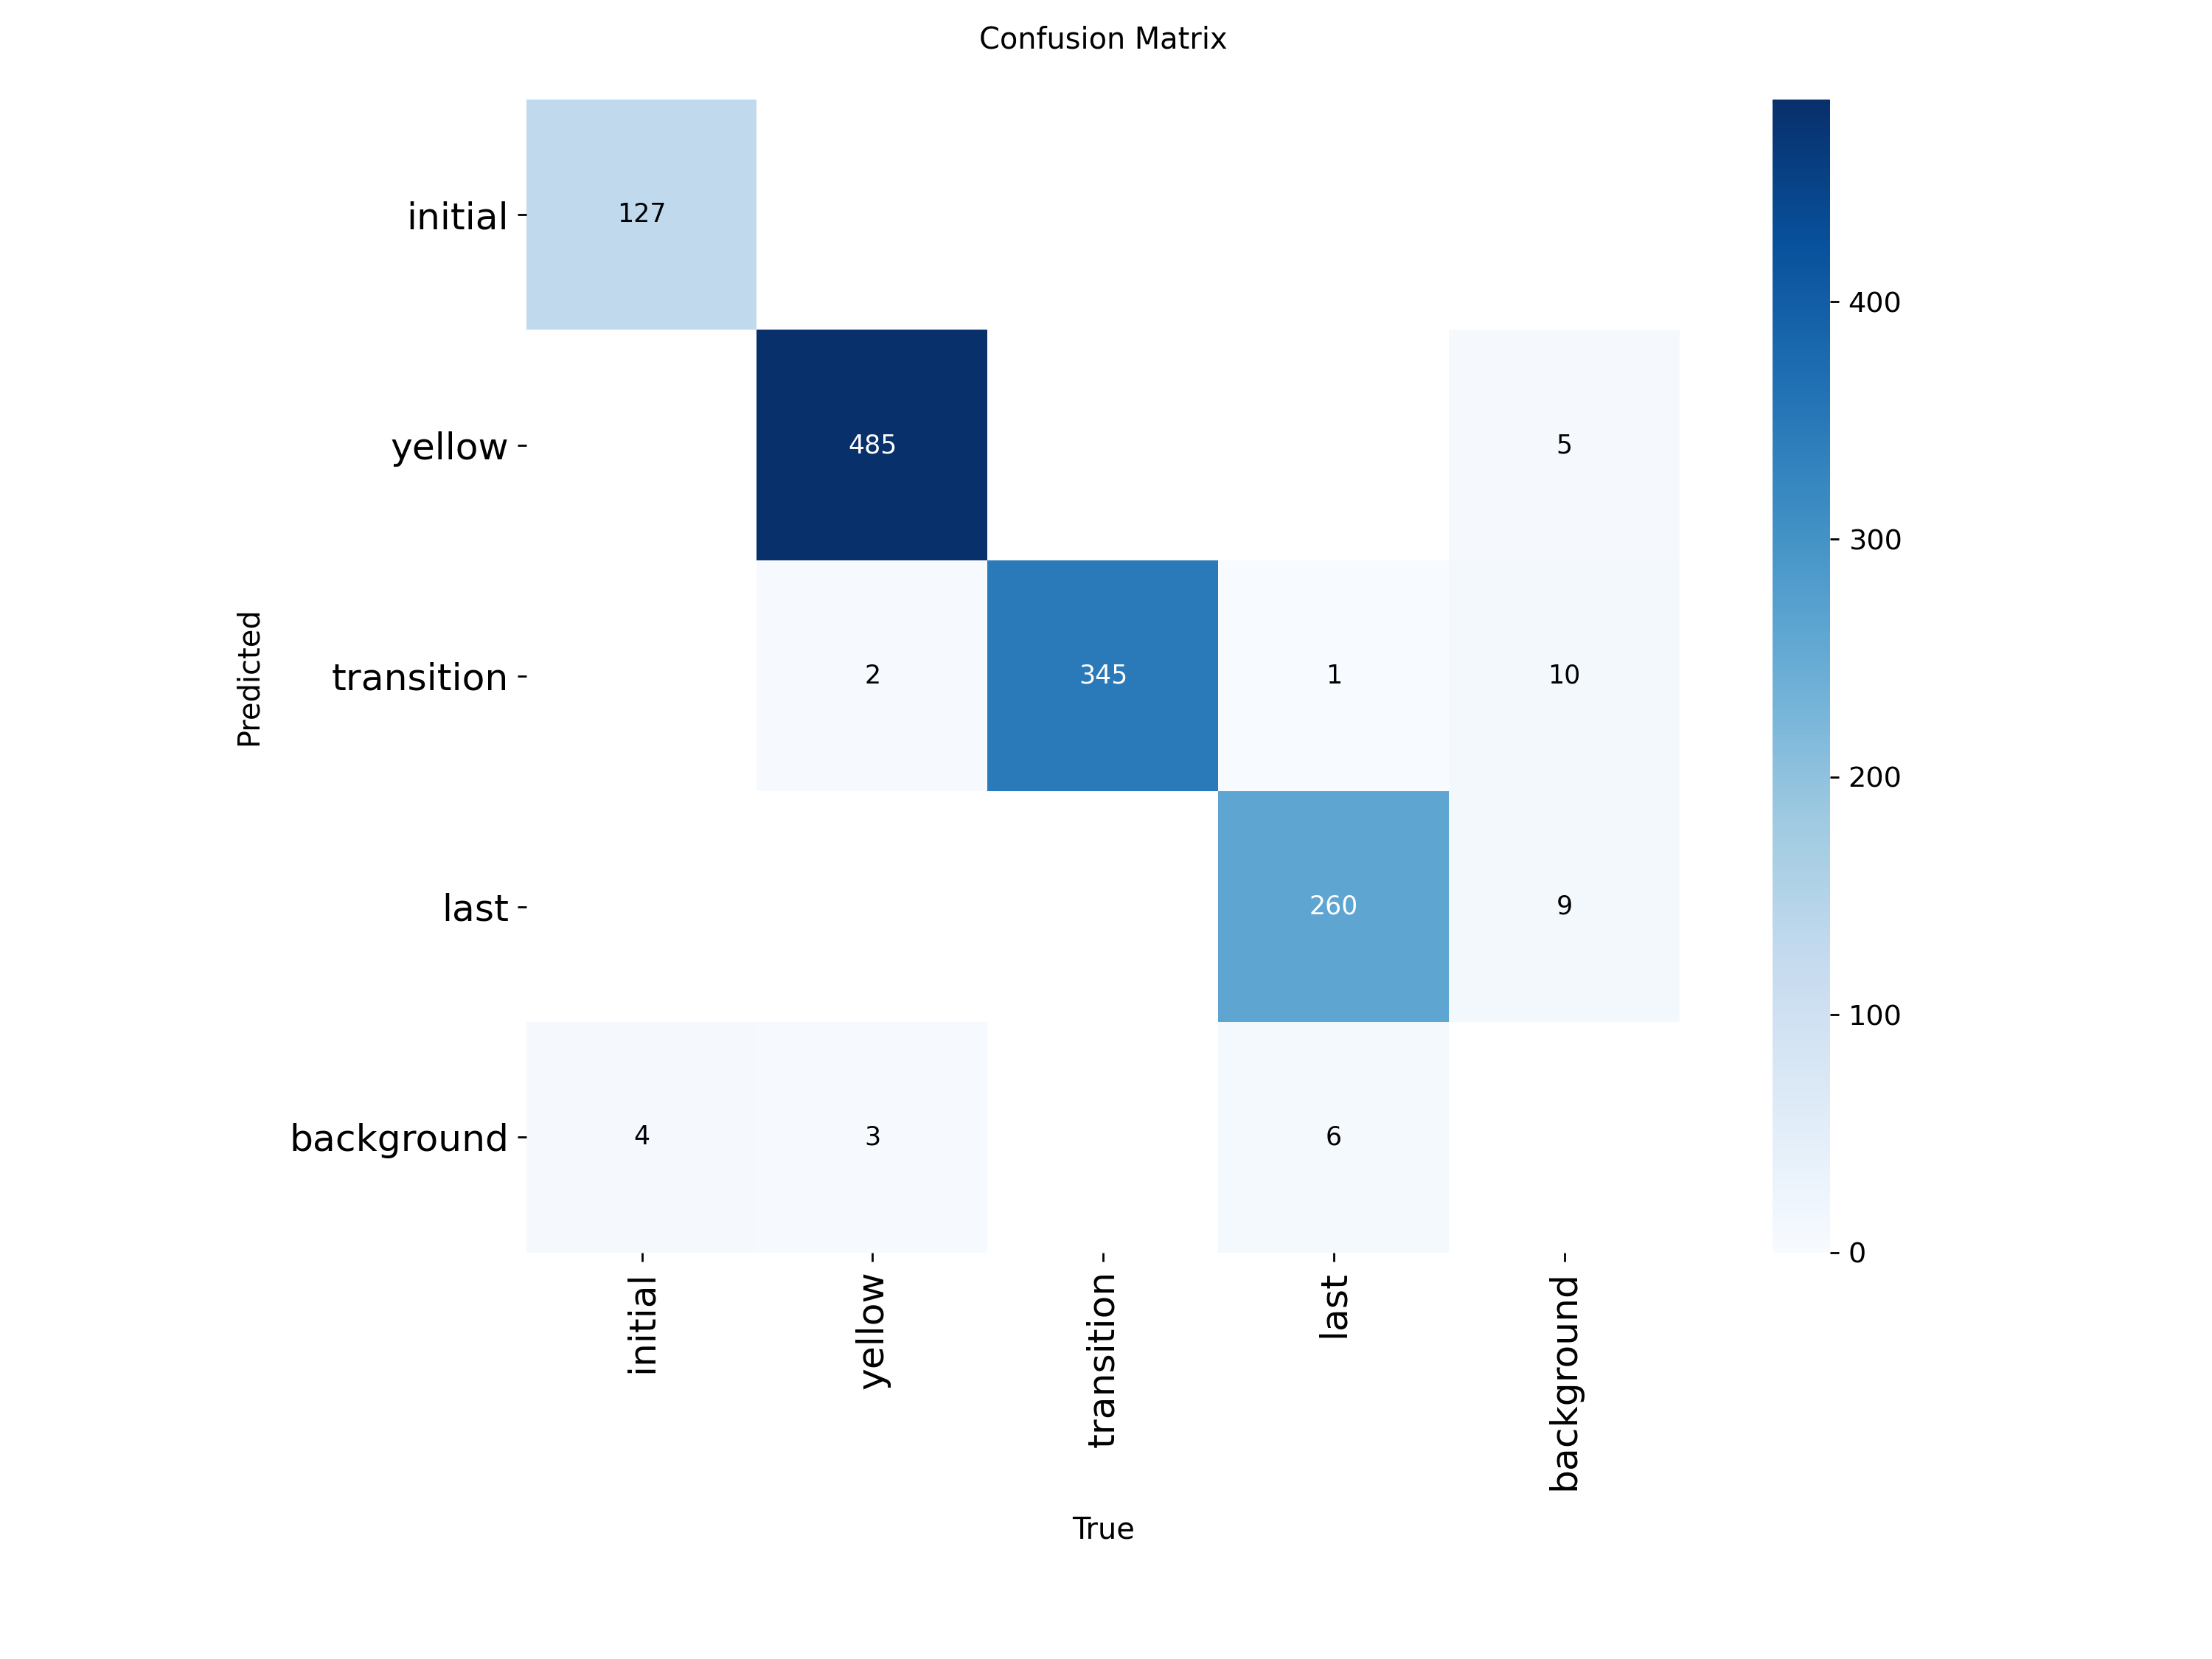

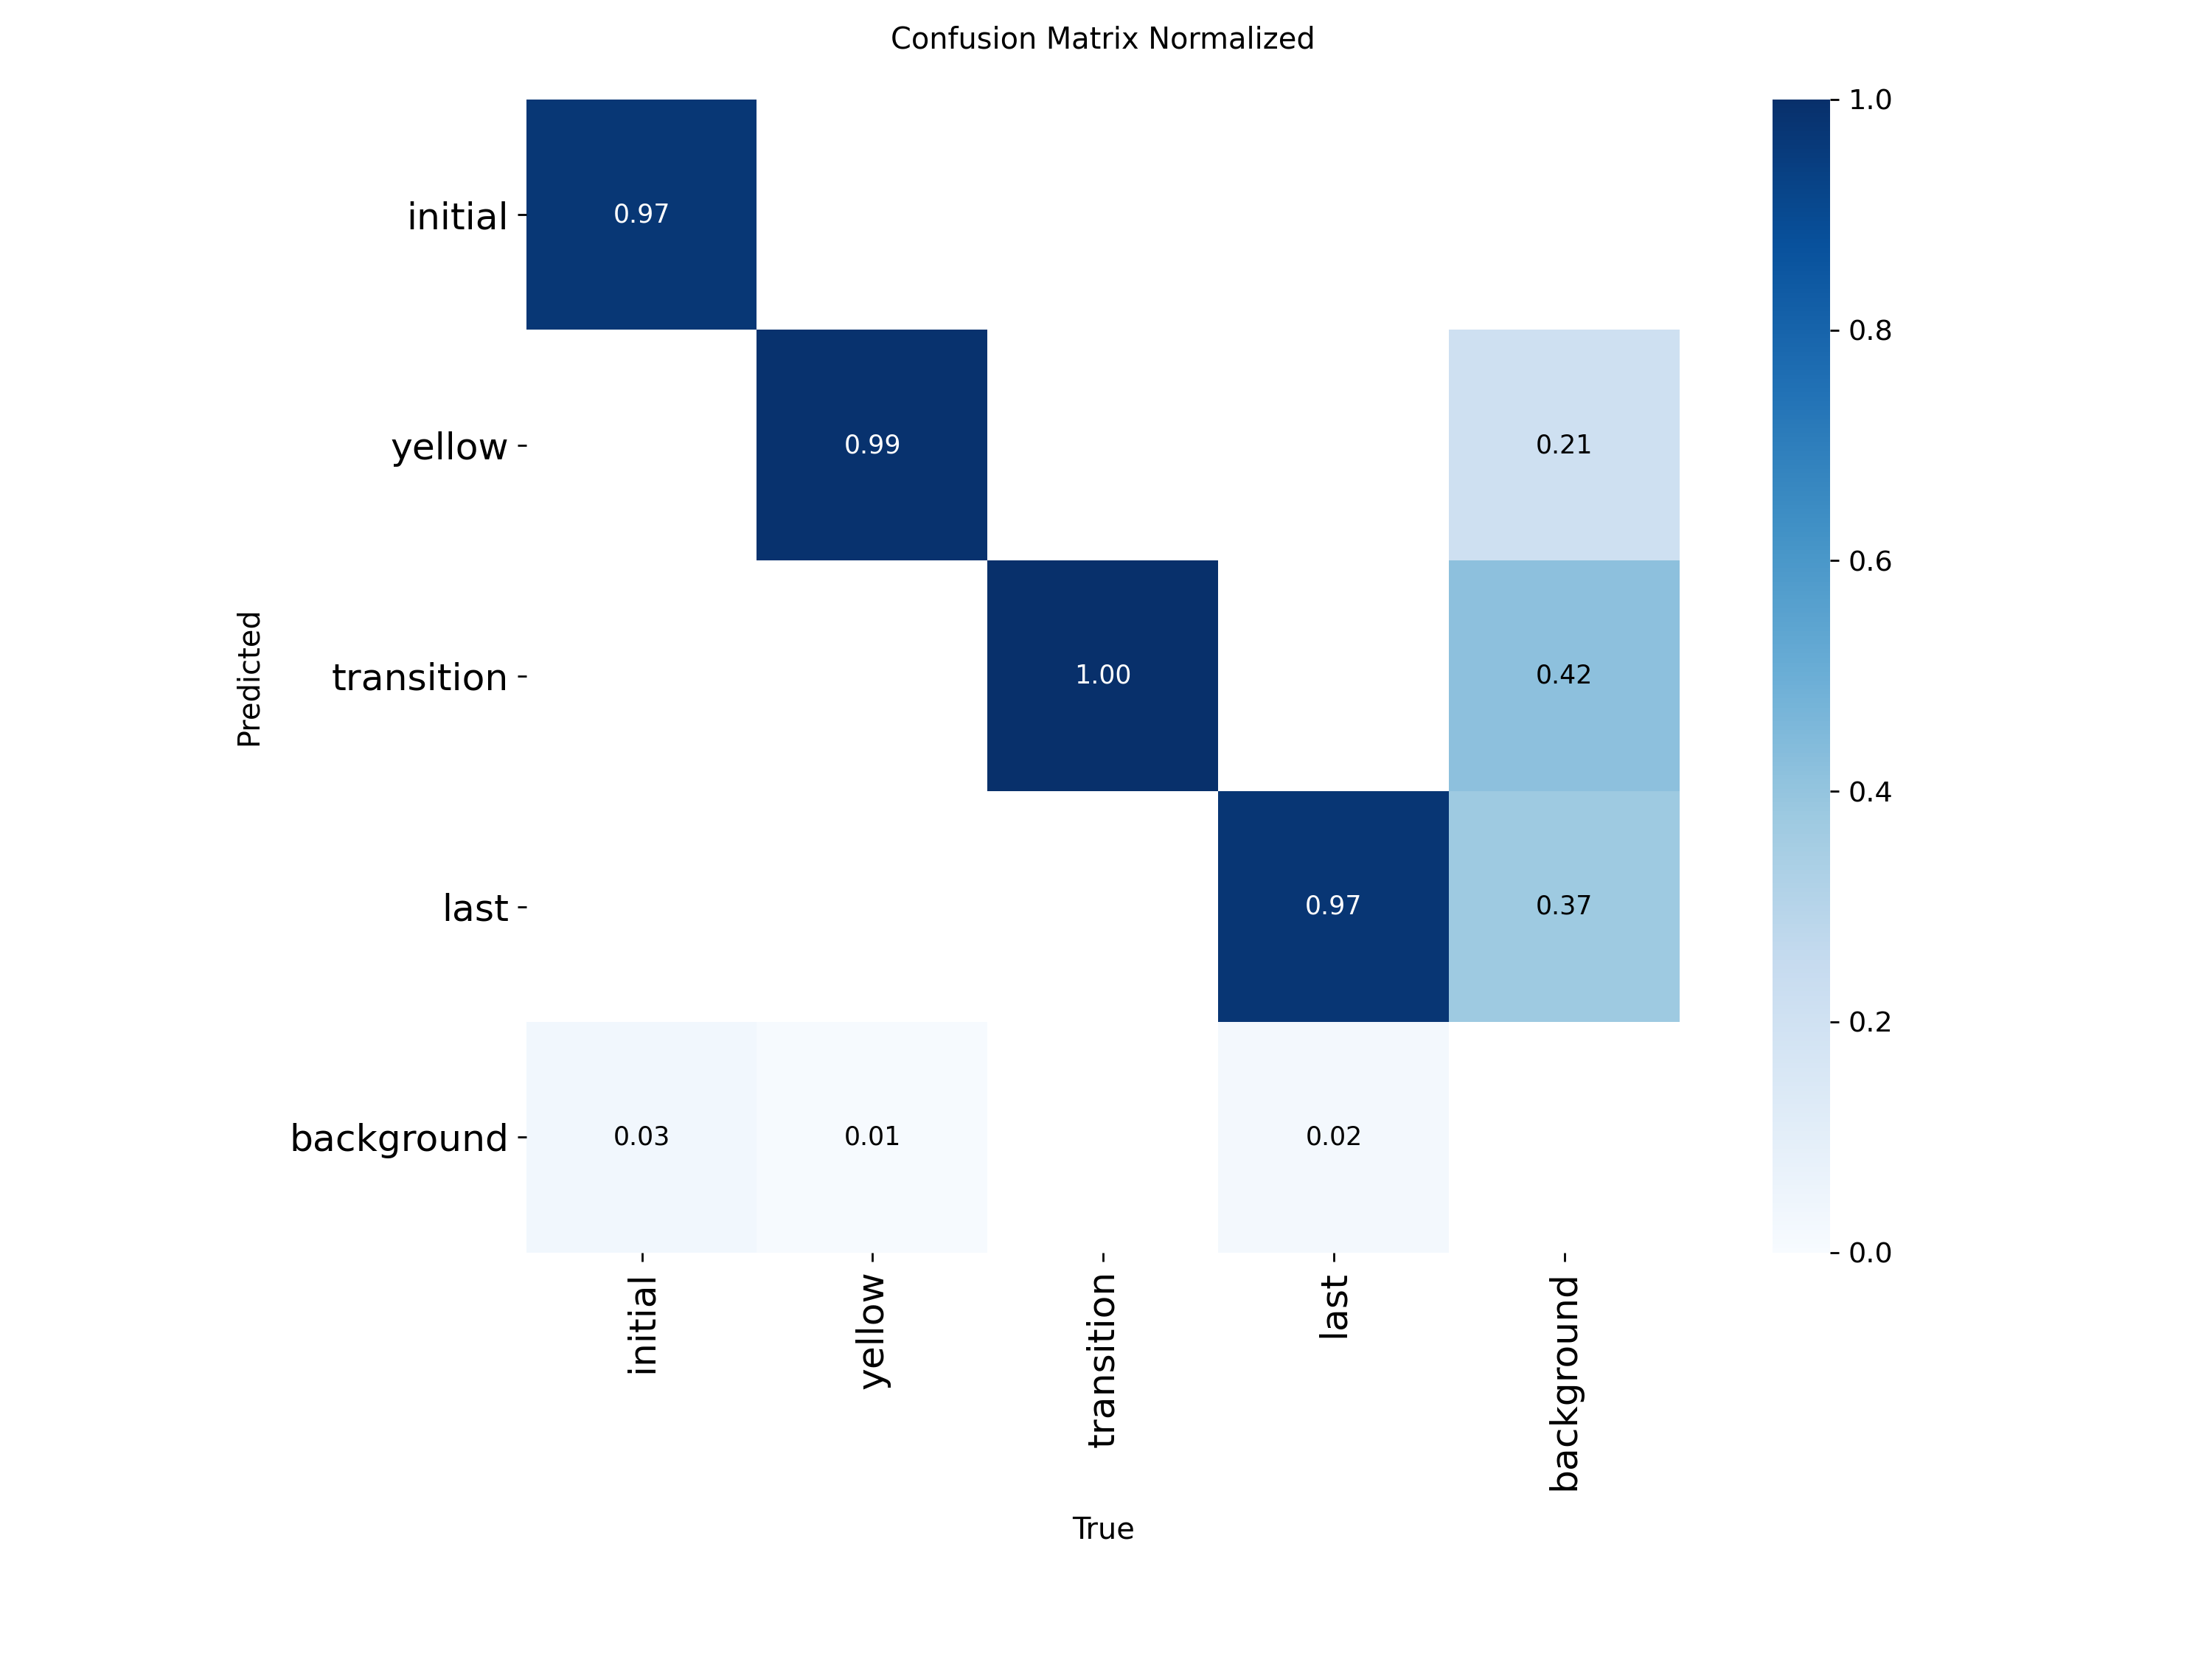

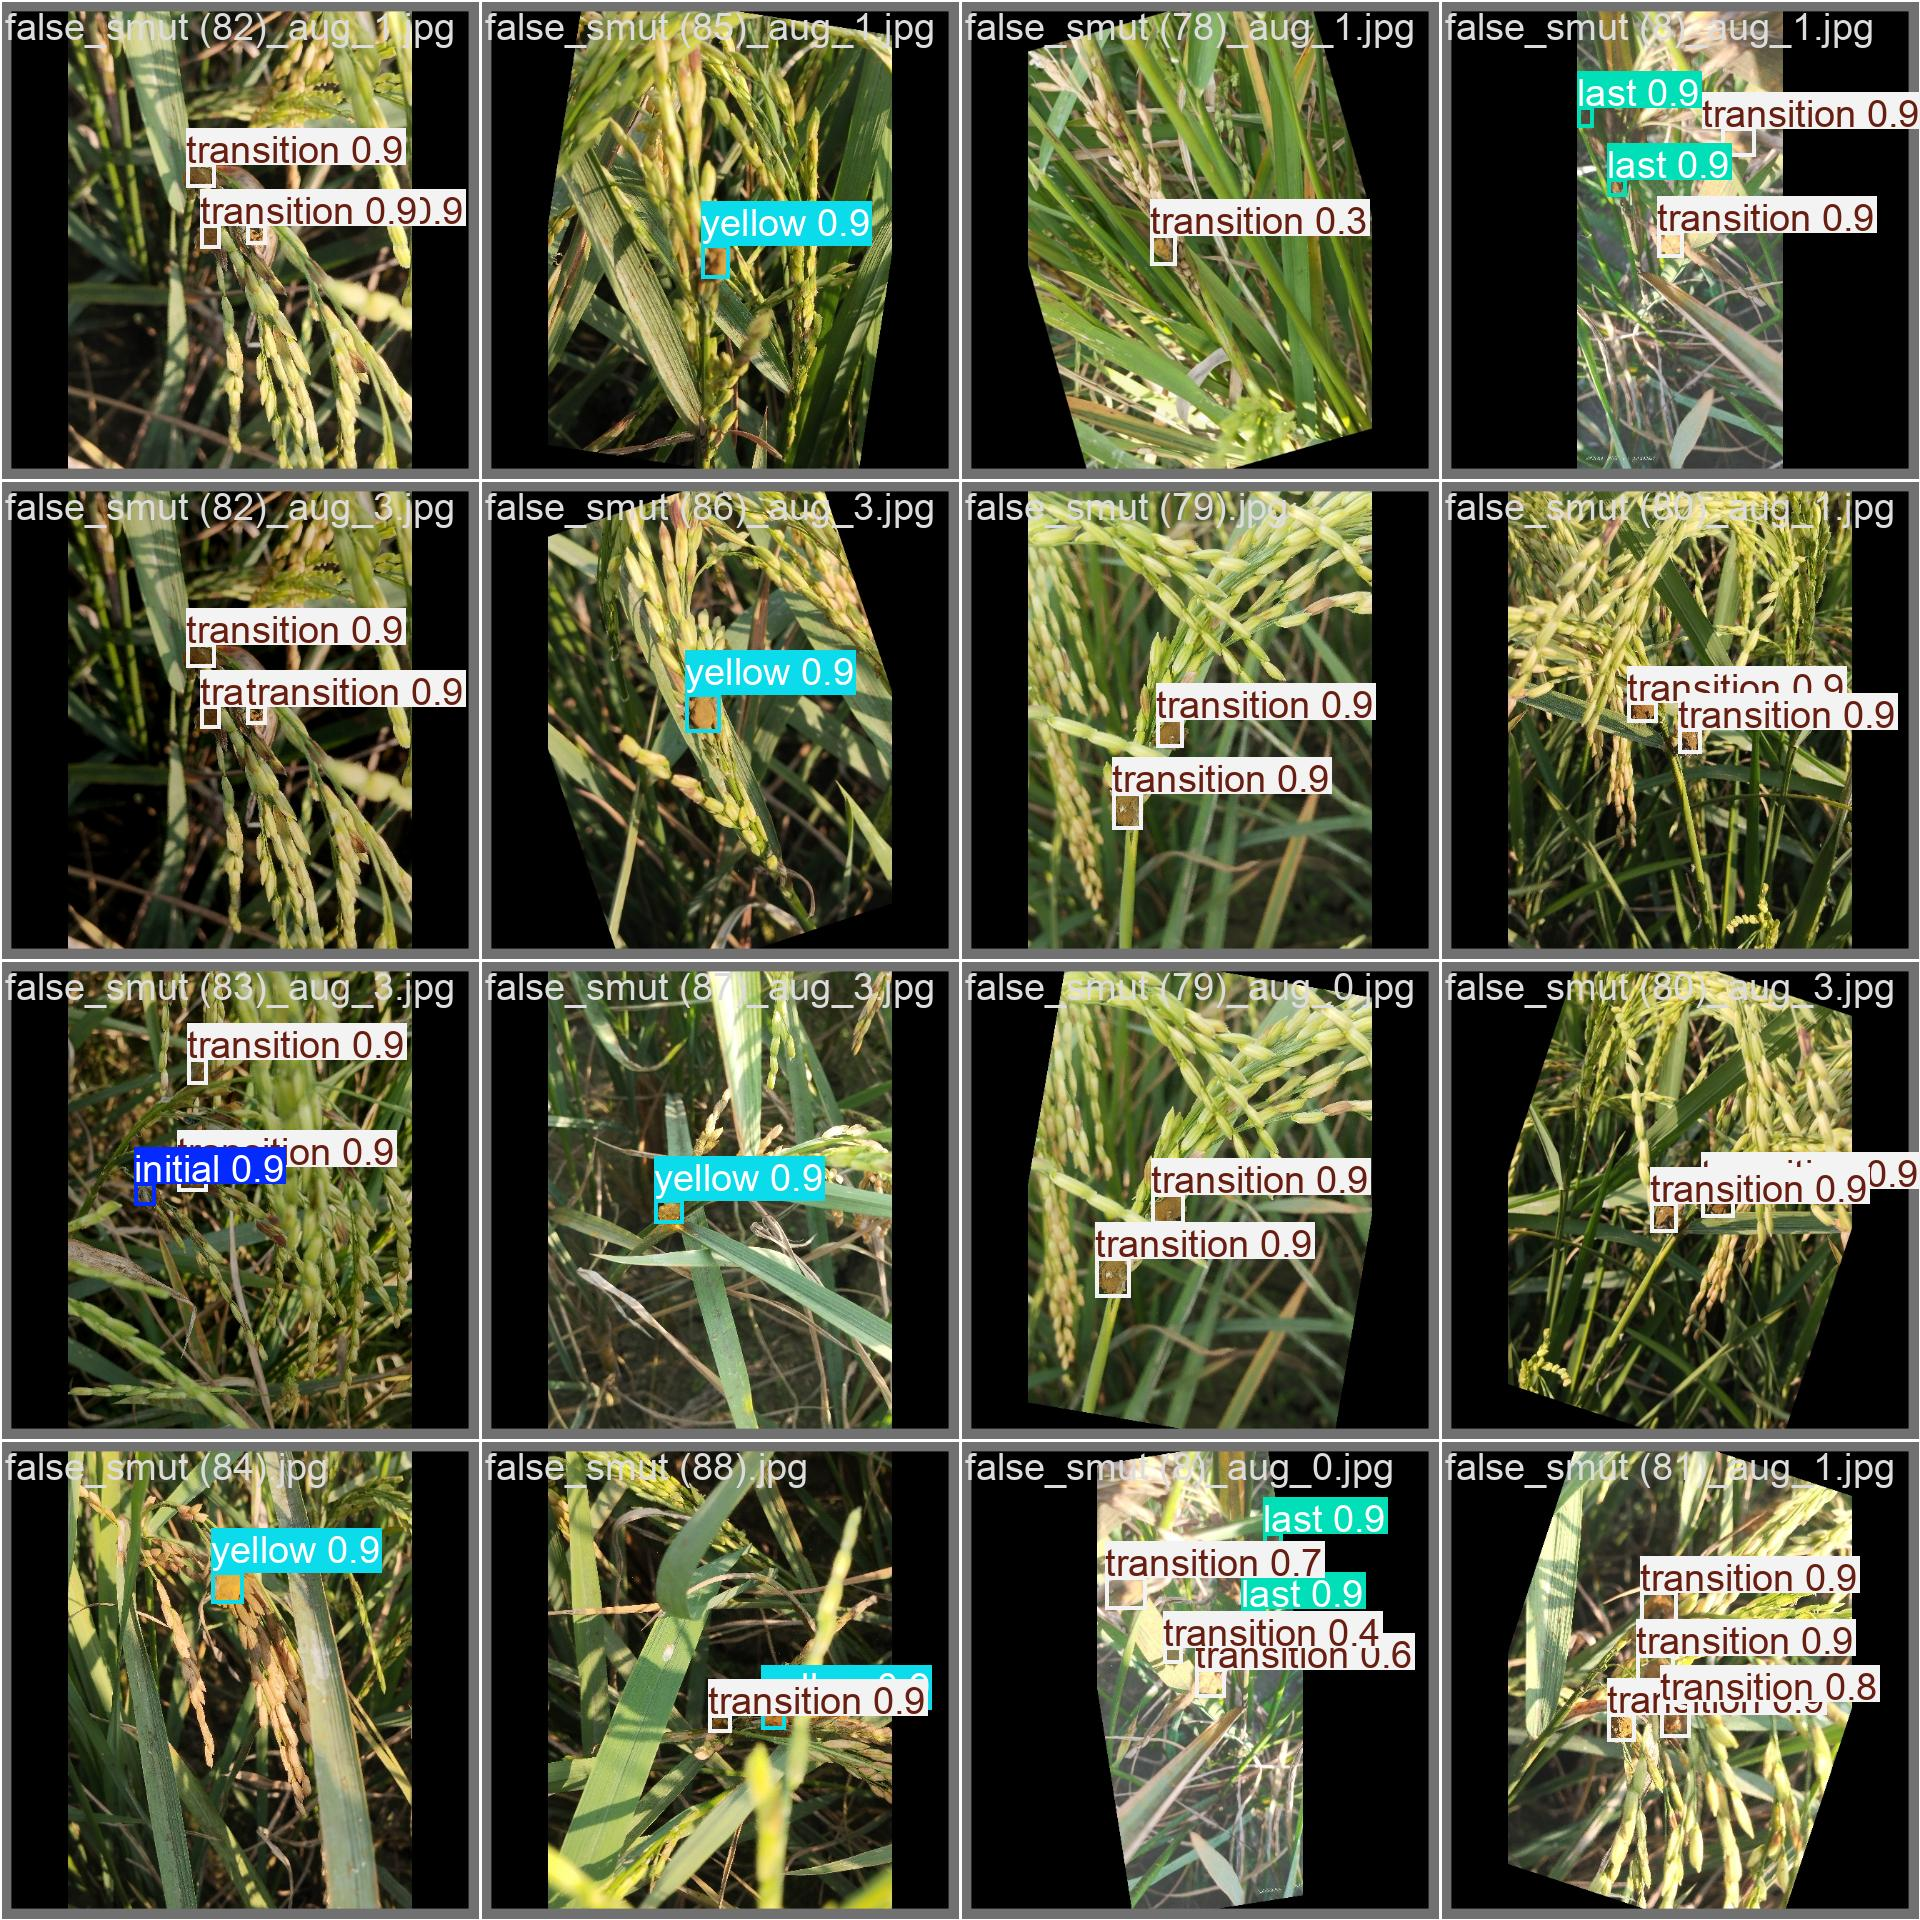

In [11]:
print("="*60)
print("  TRAINING YOLOv9")
print("="*60)

V9_RUN_DIR = f"{BASE_PATH}/runs/yolov9"
os.makedirs(V9_RUN_DIR, exist_ok=True)

model_v9 = YOLO('yolov9c.pt')
model_v9.train(
    data      = DATA_YAML,
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    device    = DEVICE,
    project   = V9_RUN_DIR,
    name      = 'train',
    exist_ok  = True,
    plots     = True,
    save      = True,
    val       = True,
    patience  = 15,
    save_period = 10,
)

v9_dest = copy_results_to_drive(V9_RUN_DIR, 'yolov9')
v9_metrics = extract_metrics(V9_RUN_DIR, 'YOLOv9')
if v9_metrics:
    SUMMARY.append(v9_metrics)
show_result_images(V9_RUN_DIR, 'YOLOv9')

### YOLOv9 — Predict on Test Images

In [12]:
best_v9 = f"{V9_RUN_DIR}/train/weights/best.pt"
model_v9 = YOLO(best_v9)
model_v9.predict(
    source    = TEST_SOURCE,
    conf      = CONF_THRES,
    save      = True,
    save_txt  = True,
    save_conf = True,
    project   = V9_RUN_DIR,
    name      = 'predict',
    exist_ok  = True,
)
copy_results_to_drive(f"{V9_RUN_DIR}/predict", 'yolov9/predict')
print("✅ YOLOv9 predictions saved.")


image 1/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (1)_aug_1.jpg: 640x640 1 yellow, 48.7ms
image 2/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (1)_aug_2.jpg: 640x640 1 yellow, 48.7ms
image 3/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (1)_aug_3.jpg: 640x640 1 yellow, 48.7ms
image 4/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (10).jpg: 640x640 2 initials, 1 yellow, 2 transitions, 31.0ms
image 5/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (10)_aug_0.jpg: 640x640 2 initials, 1 yellow, 2 transitions, 28.9ms
image 6/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (10)_aug_1.jpg: 640x640 2 initials, 1 yellow, 2 transitions, 28.6ms
image 7/20 /kaggle/input/datasets/tamimresearch/rice-false-smut/test_data/false_smut (13)_aug_2.jpg: 640x640 1 yellow, 28.8ms
image 8/20 /kaggle/input/datasets/tamimresear

---
# 📊 CELL 7: Comparison Summary & Charts

In [13]:
if not SUMMARY:
    print("⚠️  No metrics collected yet. Run training cells first.")
else:
    df_summary = pd.DataFrame(SUMMARY)
    df_summary = df_summary.set_index('version')
    print("\n" + "="*60)
    print("  FINAL COMPARISON SUMMARY")
    print("="*60)
    display(df_summary)

    # Save CSV
    summary_csv = f"{RESULTS_PATH}/comparison_summary.csv"
    df_summary.to_csv(summary_csv)
    print(f"\n✅ Summary saved to {summary_csv}")


  FINAL COMPARISON SUMMARY


,epochs,mAP50,mAP50-95,precision,recall
version,,,,,
YOLOv8,100,0.9837,0.7717,0.9788,0.9572
YOLOv10,100,0.9791,0.7547,0.9594,0.9451
YOLOv9,100,0.9929,0.8415,0.9896,0.9819



✅ Summary saved to /kaggle/working/yolo_comparison/results/comparison_summary.csv


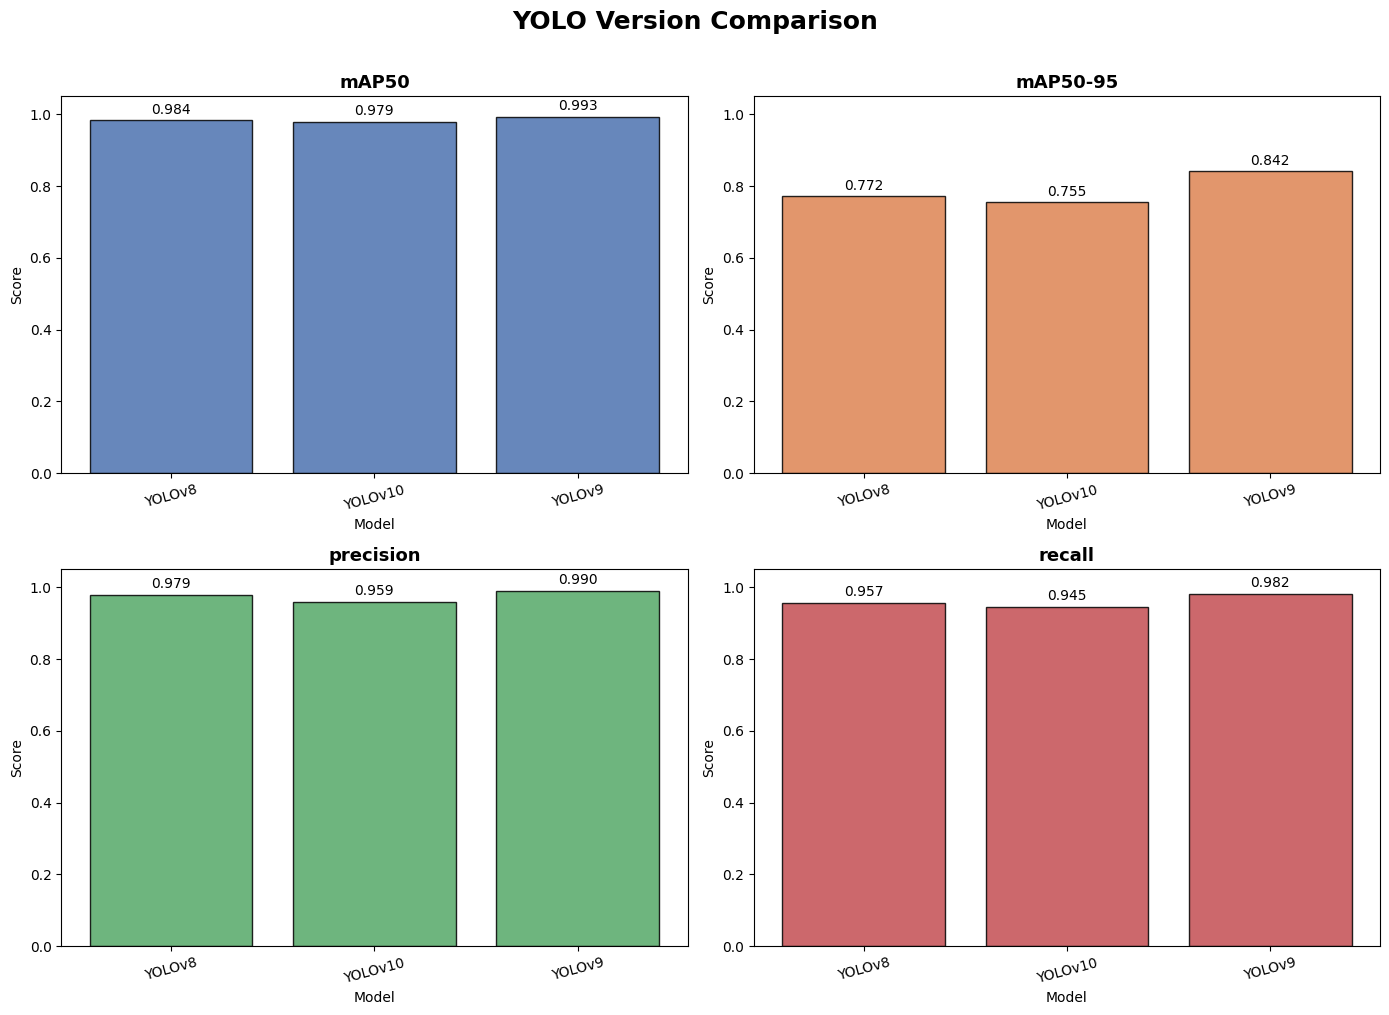

✅ Bar chart saved → /kaggle/working/yolo_comparison/results/comparison_bar_chart.png


In [14]:
# ── Comparison bar charts ──────────────────────────────────────────────────
if SUMMARY:
    df = pd.DataFrame(SUMMARY)
    metrics_to_plot = ['mAP50', 'mAP50-95', 'precision', 'recall']
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('YOLO Version Comparison', fontsize=18, fontweight='bold', y=1.01)

    for ax, metric, color in zip(axes.flat, metrics_to_plot, colors):
        bars = ax.bar(df['version'], df[metric], color=color, edgecolor='black', alpha=0.85)
        ax.set_title(metric, fontsize=13, fontweight='bold')
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('Score')
        ax.set_xlabel('Model')
        ax.tick_params(axis='x', rotation=15)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f"{bar.get_height():.3f}",
                    ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    chart_path = f"{RESULTS_PATH}/comparison_bar_chart.png"
    plt.savefig(chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Bar chart saved → {chart_path}")

/tmp/ipykernel_57/3072931871.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(SUMMARY))


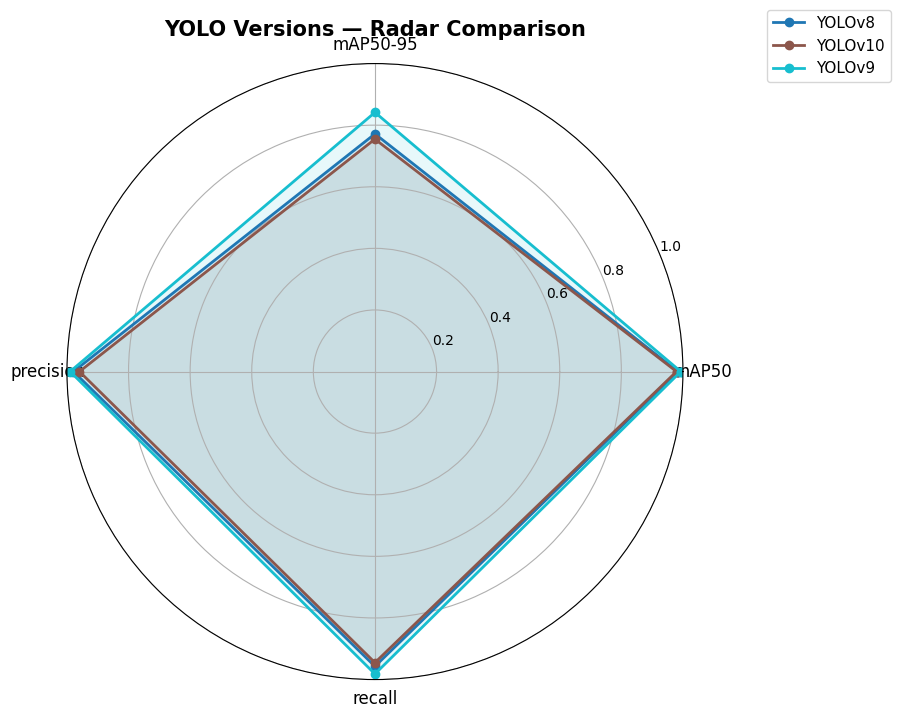

✅ Radar chart saved → /kaggle/working/yolo_comparison/results/comparison_radar_chart.png


In [15]:
# ── Radar chart ────────────────────────────────────────────────────────────
if SUMMARY:
    import matplotlib.patches as mpatches
    from matplotlib.path import Path as MPath

    categories = ['mAP50', 'mAP50-95', 'precision', 'recall']
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    cmap = plt.cm.get_cmap('tab10', len(SUMMARY))

    for i, row in enumerate(SUMMARY):
        values = [row.get(c, 0) for c in categories]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=row['version'], color=cmap(i))
        ax.fill(angles, values, alpha=0.1, color=cmap(i))

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_title('YOLO Versions — Radar Comparison', fontsize=15, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)

    radar_path = f"{RESULTS_PATH}/comparison_radar_chart.png"
    plt.savefig(radar_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Radar chart saved → {radar_path}")

/tmp/ipykernel_57/2667293265.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(version_run_dirs))


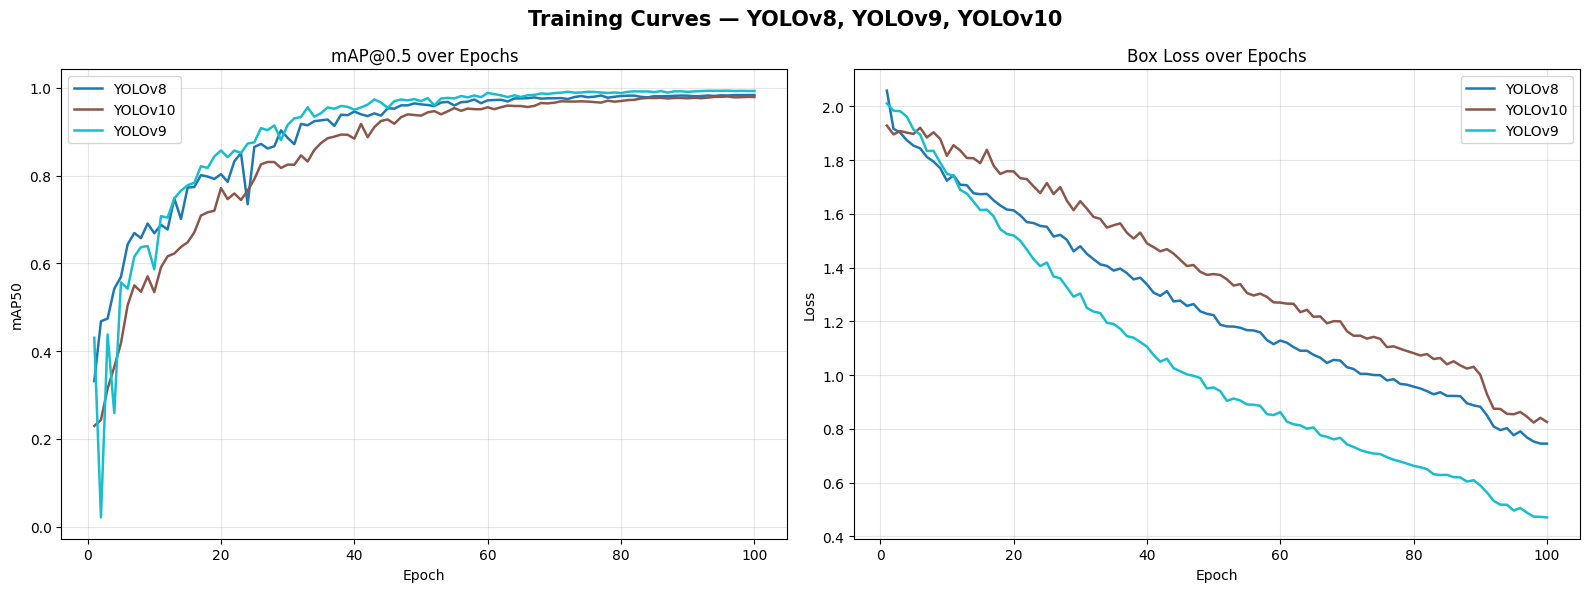

✅ Training curves saved → /kaggle/working/yolo_comparison/results/comparison_training_curves.png


In [16]:
# ── mAP50 Training Curves (all versions overlaid) ─────────────────────────
version_run_dirs = {
    'YOLOv8' : V8_RUN_DIR,
    'YOLOv10': V10_RUN_DIR,
    'YOLOv9' : V9_RUN_DIR,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Training Curves — YOLOv8, YOLOv9, YOLOv10', fontsize=15, fontweight='bold')
cmap = plt.cm.get_cmap('tab10', len(version_run_dirs))

for i, (vname, run_dir) in enumerate(version_run_dirs.items()):
    csvs = glob.glob(f"{run_dir}/**/results.csv", recursive=True)

    if csvs:
        df = pd.read_csv(csvs[0])
        df.columns = df.columns.str.strip()
        map50_col = next((c for c in df.columns if 'mAP50' in c and '95' not in c), None)
        loss_col  = next((c for c in df.columns
                          if 'box_loss' in c.lower() or 'train/box' in c.lower()), None)
    else:
        print(f"  ⚠️  No results.csv found for {vname}, skipping curve.")
        continue

    ep = range(1, len(df) + 1)
    if map50_col and map50_col in df.columns:
        axes[0].plot(ep, df[map50_col], label=vname, color=cmap(i), linewidth=1.8)
    if loss_col and loss_col in df.columns:
        axes[1].plot(ep, df[loss_col],  label=vname, color=cmap(i), linewidth=1.8)

axes[0].set_title('mAP@0.5 over Epochs');  axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('mAP50')
axes[1].set_title('Box Loss over Epochs'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
for ax in axes:
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
curves_path = f"{RESULTS_PATH}/comparison_training_curves.png"
plt.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Training curves saved → {curves_path}")


---
# 📁 CELL 8: Final Output Summary


In [17]:
print("\n" + "="*60)
print("  SAVED OUTPUT STRUCTURE")
print("="*60)

for root, dirs, files in os.walk(RESULTS_PATH):
    level = root.replace(RESULTS_PATH, '').count(os.sep)
    indent = '  ' * level
    folder = os.path.basename(root)
    print(f"{indent}📂 {folder}/")
    if level < 3:
        sub = '  ' * (level + 1)
        for f in files:
            print(f"{sub}📄 {f}")

print(f"\n✅ All results stored at: {RESULTS_PATH}")
print("   Download via Kaggle notebook Output tab ➜ /kaggle/working/")



  SAVED OUTPUT STRUCTURE
📂 results/
  📄 comparison_bar_chart.png
  📄 comparison_training_curves.png
  📄 comparison_radar_chart.png
  📄 comparison_summary.csv
  📂 yolov8/
    📂 predict/
      📄 false_smut (13)_aug_3.jpg
      📄 false_smut (1)_aug_1.jpg
      📄 false_smut (10)_aug_1.jpg
      📄 false_smut (7).jpg
      📄 false_smut (2).jpg
      📄 false_smut (1)_aug_2.jpg
      📄 false_smut (14)_aug_1.jpg
      📄 false_smut (16)_aug_0.jpg
      📄 false_smut (14).jpg
      📄 false_smut (9)_aug_3.jpg
      📄 false_smut (13)_aug_2.jpg
      📄 false_smut (14)_aug_0.jpg
      📄 false_smut (10).jpg
      📄 false_smut (16)_aug_1.jpg
      📄 false_smut (2)_aug_1.jpg
      📄 false_smut (10)_aug_0.jpg
      📄 false_smut (1)_aug_3.jpg
      📄 false_smut (2)_aug_0.jpg
      📄 false_smut (6)_aug_2.jpg
      📄 false_smut (6)_aug_3.jpg
      📂 labels/
    📂 train/
      📄 results.png
      📄 results.csv
      📄 train_batch2.jpg
      📄 val_batch2_pred.jpg
      📄 confusion_matrix.png
      📄 BoxF1_cur

In [21]:
import shutil

shutil.make_archive('/kaggle/working/yolo_comparison', 'zip', '/kaggle/working/yolo_comparison')

'/kaggle/working/yolo_comparison.zip'